In [1]:
#%%time
import os
import re
import gzip
import math
import random
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

from ast import literal_eval
import warnings
# 忽略 FutureWarning 类型警告
warnings.simplefilter(action='ignore', category=FutureWarning)
# 忽略特定类型的警告：忽略 scanpy包中含有 ignore 的 UserWarning 类型警告
warnings.filterwarnings("ignore", category=UserWarning, module="scanpy")
# 禁用 pandas 包中的 SettingWithCopyWarning 类型警告  
pd.options.mode.chained_assignment = None  # 或 'raise' 表示引发异常

import inferECC
from inferECC import *

from scipy.stats import ttest_ind,mannwhitneyu,ks_2samp

species value: hg38
species == 'mm10':  False


In [53]:
### anno ecdna2gene oncogene pathway
### import ecdna2gene2pathway function

import warnings
import scanpy as sc
from ast import literal_eval
from collections import Counter

cancer_gene_tb = pd.read_csv("D:/02.project/18.ecDNA/02.method/ref/hg19/cancer_gene_census_20240307.txt",sep="\t")
cancer_gene_list = list(cancer_gene_tb["Gene Symbol"].unique())

# DataFrame :: gene_unique_list is the column list of elements that match oncogenes
def custom_transform(element):
    if isinstance(element, list):
        # Extract the intersection of the element list with oncogene_list
        return list(set(element) & set(cancer_gene_list))
    else:
        # If the element is NaN, then return NaN
        return element
### step 1
# Apply the custom function custom_transform to the gene_unique_list column
#df['oncogene'] = df['gene_unique_list'].apply(custom_transform)

# Define a function to process elements in the oncogene column:: convert oncogene_nor element value 0 to []
def process_gene_list(item):
    # If the element is the integer 0, return an empty list
    if item == 0:
        return []
    # Otherwise, return the original element
    else:
        return item
# Define a function to process elements in the oncogene_nor column:: merge oncogene_nor list
def merge_gene_list(gene_list):
    # Create an empty list to store the results
    result = []
    for item in gene_list:
        # If the element is a list, add its elements to the result
        if isinstance(item, list):
            result.extend(item)
    return result
# Define a function to process elements in the oncogene_nor column
def process_oncogene_nor(oncogene_nor, top_n=15):
    # Use Counter to count the frequency of elements
    counter = Counter(oncogene_nor)
    # Extract the top_n elements with the highest frequency
    most_common = counter.most_common(top_n) # 6/15
    # Form a list with these top_n elements
    result = [item[0] for item in most_common]
    return result
### Main function merge
def group_merge(df=pd.DataFrame(), group_columns_name="group", raw_columns_name="oncogene"):
    df_ecdna_gene = df.copy()
    # Use the apply function
    df_ecdna_gene[raw_columns_name+"_nor"] = df_ecdna_gene[raw_columns_name].apply(process_gene_list)
    # Use groupby and apply functions
    df_ecdna_gene_grouped = df_ecdna_gene.groupby(group_columns_name)[raw_columns_name+"_nor"].apply(merge_gene_list).reset_index()
    # Convert the label column to Categorical type and specify the order of categories
    df_ecdna_gene_grouped[group_columns_name] = pd.Categorical(df_ecdna_gene_grouped[group_columns_name],
                                                    categories=list(df_ecdna_gene[group_columns_name].unique()),
                                                    ordered=True)
    # Use the sort_values function to sort
    df_ecdna_gene_grouped = df_ecdna_gene_grouped.sort_values(group_columns_name)
    # Use the apply function
    df_ecdna_gene_grouped['most_'+raw_columns_name+"_nor"] = df_ecdna_gene_grouped[raw_columns_name+"_nor"].apply(process_oncogene_nor)
    return df_ecdna_gene_grouped

### step 2
# Apply the custom function group_merge to the gene oncogene column
#df_merge = group_merge(df_ecdna_gene_oncogene, "group")



###共性基因功能注释：：
# highest_expr_top_n
import gseapy as gp
from gseapy.plot import barplot, dotplot
"""
names = gp.get_library_name()
# Create a DataFrame from the list
df = pd.DataFrame(names, columns=['Name'])
# Save the DataFrame to a CSV file
df.to_csv("./fig/gseapy_gene-sets.txt", index=False)
"""

import pandas as pd
# 定义一个函数来处理字符串
def process_term(term):
    # 检查倒数第12个到倒数第9个字符是否为'(GO:'
    if term[-12:-8] == '(GO:':
        # 如果是，则删除倒数第11个字符之后的所有字符
        return term[:-12]
    else:
        # 否则，返回原字符串
        return term

def gp_enrichr(gene_list,sample,path,gene_sets):
    # 假设你已经有了差异基因列表
    diff_genes = gene_list
    #diff_genes = new_df[new_df["cluster"]=="C3"]["gene"].to_list()
    #diff_genes = new_df["gene"].to_list()
    # 运行GSEA
    # enrichr库包含了大量的基因集，选择其中的一个，例如'KEGG_2019_Human'\'MSigDB_Hallmark_2020'
    enr = gp.enrichr(gene_list=diff_genes,
                     gene_sets=['MSigDB_Hallmark_2020',
                                #'KEGG_2021_Human',
                                #'GO_Biological_Process_2023',
                                #'GO_Molecular_Function_2023',
                                #'GO_Cellular_Component_2023'
                               ],
                     #outdir='./fig/pdac/gseapy',
                     outdir=None,
                     cutoff=0.05)
    
    enr.results["Term_raw"]=enr.results["Term"]
    # 使用apply函数应用到'Term'列
    enr.results["Term"] = enr.results["Term"].apply(process_term)
    # trim (go:...)
    #enr.results["Term"] = enr.results["Term"].str.split(" \(GO").str[0]
    # 根据'A'列的值对df进行排序
    enr_results_sorted = enr.results.sort_values(by='P-value')
    enr_results_sorted['cluster'] = sample
    enr_results_sorted.to_csv(path+"/"+sample+"_enrichr_result.tsv",sep="\t",index=True)
    
    # categorical scatterplot
    #ax = barplot(enr_results_sorted,
    #             #column="Adjusted P-value",
    #             column="P-value",
    #             #group='Gene_set', # set group, so you could do a multi-sample/library comparsion
    #             #size=10,
    #             top_term=30,
    #             #figsize=(10,6*len(enr.results[enr.results["P-value"] <= 0.05])/50),
    #             figsize=(35,12),
    #             color=['blue'] # set colors for group
    #             #color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue'}
    #             )
    #plt.grid(False)
    #plt.savefig(path+"/"+sample+"_enrichr_barplot.pdf")
    return enr_results_sorted

In [2]:
def get_all_folders(path):
    folders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
    return folders

def process_tr(tr: str) -> str:
    if tr.endswith("NT"):
        return "notumor"
    else:
        return "tumor"

In [3]:
import numpy as np
import scipy

#### adata_fi_back
#reference_series = adata_merged.var["cov6_ave"]
reference = pd.read_csv("./fig_100k_obs-ref/11sample_ref/f02-cpr_ref_var.tsv",sep="\t",index_col=0)
#reference_series = reference["cov6_ave"]
reference_series = reference["cov_mean3std"].copy()
def adata_fi_background(adata, reference = reference_series):
    # 步骤1: 获取参考序列
    reference = reference.copy()
    
    # 步骤2: 创建一个与adata.var_names对应的参考序列，不存在的用0填充
    adata = adata.copy()
    ref_values = pd.Series(0, index=adata.var_names)
    ref_values.update(reference)
    
    # 步骤3: 将每个细胞的表达值减去参考序列的值
    # 如果adata.X是稀疏矩阵，需要先转换为密集格式
    if scipy.sparse.issparse(adata.X):
        adata.X = adata.X.toarray()
    # 减去参考值
    adata.X = adata.X - ref_values.values
    
    # 步骤4: 使用clip函数将小于0的值替换为0
    adata.X = np.clip(adata.X, a_min=0, a_max=None)
    
    return adata
    

In [4]:
import warnings
import scanpy as sc
adata_raw_list = list()
adata_fbg_list = list()
# 忽略来自 scanpy 的警告
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    all_path = "E:/05.project/04.ecDNA/02.result/result_esca/ESCA_peidui/"
    sample_list = get_all_folders(all_path)
    for sample in sample_list:
        lib_dir = all_path+sample
        print(lib_dir)
        adata_sample = sc.read(lib_dir+"/ks_uniform_qsub/cellXecDNA_fi.matrix.h5ad")
        #adata_raw_list.append(adata_sample)
        
        #adata_sample_fbg = adata_fi_background(adata=adata_sample)
        adata_sample_fbg = adata_sample.copy()
        
        # 筛选在大于3个细胞中存在的ecDNA
        sc.pp.filter_cells(adata_sample_fbg, min_genes=3)
        sc.pp.filter_genes(adata_sample_fbg, min_cells=3)
        sample = re.sub("(-fragments.tsv.gz|-atac_fragments.tsv.gz)$", "", sample)
        adata_sample_fbg.obs["sample"]=sample
        adata_sample_fbg.var["sample"]=sample
        adata_sample_fbg.var['ecDNA'] = adata_sample_fbg.var.index
            
        adata_sample_fbg.var['cell_frequency_cov3pos'] = (adata_sample_fbg.X >= 3).mean(axis=0)
        adata_sample_fbg.var['cell_number_cov3pos'] = (adata_sample_fbg.X >= 3).sum(axis=0)
        adata_sample_fbg.obs['ecDNA_number_cov3pos'] = (adata_sample_fbg.X >= 3).sum(axis=1)
            
        adata_sample_fbg.var['Max_coverage_in_sample'] = np.max(adata_sample_fbg.X, axis=0)
        adata_sample_fbg.var['Ave_coverage_in_sample'] = np.mean(adata_sample_fbg.X, axis=0)
        adata_sample_fbg.var['Median_coverage_in_sample'] = np.median(adata_sample_fbg.X, axis=0)
        adata_fbg_list.append(adata_sample_fbg)
        
        #adata_sample_fbg.write_h5ad(lib_dir+"/ks_uniform_qsub/cellXecDNA_fi_fbg_m3std.h5ad")
        pass

E:/05.project/04.ecDNA/02.result/result_esca/ESCA_peidui/P11_LN_N
E:/05.project/04.ecDNA/02.result/result_esca/ESCA_peidui/P11_LN_NR
E:/05.project/04.ecDNA/02.result/result_esca/ESCA_peidui/P11_LN_R
E:/05.project/04.ecDNA/02.result/result_esca/ESCA_peidui/P11_T_0


In [5]:
len(adata_fbg_list)

4

In [6]:
##### input

In [7]:
####去除背景前
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# 从adata_combined对象中提取每种癌症类型的每个样本的ecDNA数量
data = []
for adata_sample in adata_fbg_list:
    #cancer = adata_sample.obs["NT"].to_list()[0]
    sample = adata_sample.obs["sample"].to_list()[0]
    ecdna_count = adata_sample.shape[1]  # ecDNA数量等于adata的列数
    cell_count = adata_sample.shape[0]  # cell数量等于adata的行数
    data.append((sample, ecdna_count, cell_count))
    pass
df_cancer_sample = pd.DataFrame(data, columns=['sample', 'ecDNA_count','cell_count'])
df_cancer_sample = df_cancer_sample.sort_values(by=["sample"])
df_cancer_sample

,sample,ecDNA_count,cell_count
0,P11_LN_N,97,124
1,P11_LN_NR,151,79
2,P11_LN_R,351,188
3,P11_T_0,126,379


In [8]:
####去除背景后
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# 从adata_combined对象中提取每种癌症类型的每个样本的ecDNA数量
data = []
for adata_sample in adata_fbg_list:
    #cancer = adata_sample.obs["NT"].to_list()[0]
    sample = adata_sample.obs["sample"].to_list()[0]
    ecdna_count = adata_sample.shape[1]  # ecDNA数量等于adata的列数
    cell_count = adata_sample.shape[0]  # cell数量等于adata的行数
    data.append((sample, ecdna_count, cell_count))
    pass
df_cancer_sample = pd.DataFrame(data, columns=['sample', 'ecDNA_count','cell_count'])
df_cancer_sample = df_cancer_sample.sort_values(by=["sample"])
df_cancer_sample

,sample,ecDNA_count,cell_count
0,P11_LN_N,43,118
1,P11_LN_NR,69,46
2,P11_LN_R,259,124
3,P11_T_0,78,356


In [8]:
df_cancer_sample['log10_ecDNA_count'] = np.log10(df_cancer_sample['ecDNA_count']+1)
df_cancer_sample['log10_cell_count'] = np.log10(df_cancer_sample['cell_count']+1)
#df_cancer_sample.to_csv('./fig_100k_merge_3/stat_cov3/f01-df_cancer_sample.tsv', sep='\t', index=False)
df_cancer_sample

,sample,ecDNA_count,cell_count,log10_ecDNA_count,log10_cell_count
0,P11_LN_N,97,124,1.991226,2.096910
1,P11_LN_NR,151,79,2.181844,1.903090
2,P11_LN_R,351,188,2.546543,2.276462
3,P11_T_0,126,379,2.103804,2.579784


In [9]:
### adata_fbg_list tracing
adata_fbg_list

[AnnData object with n_obs × n_vars = 124 × 97
     obs: 'barcode', 'sample_raw', 'sample', 'n_genes', 'ecDNA_number_cov3pos'
     var: 'chr_100k', 'n_cells', 'sample', 'ecDNA', 'cell_frequency_cov3pos', 'cell_number_cov3pos', 'Max_coverage_in_sample', 'Ave_coverage_in_sample', 'Median_coverage_in_sample',
 AnnData object with n_obs × n_vars = 79 × 151
     obs: 'barcode', 'sample_raw', 'sample', 'n_genes', 'ecDNA_number_cov3pos'
     var: 'chr_100k', 'n_cells', 'sample', 'ecDNA', 'cell_frequency_cov3pos', 'cell_number_cov3pos', 'Max_coverage_in_sample', 'Ave_coverage_in_sample', 'Median_coverage_in_sample',
 AnnData object with n_obs × n_vars = 188 × 351
     obs: 'barcode', 'sample_raw', 'sample', 'n_genes', 'ecDNA_number_cov3pos'
     var: 'chr_100k', 'n_cells', 'sample', 'ecDNA', 'cell_frequency_cov3pos', 'cell_number_cov3pos', 'Max_coverage_in_sample', 'Ave_coverage_in_sample', 'Median_coverage_in_sample',
 AnnData object with n_obs × n_vars = 379 × 126
     obs: 'barcode', 'sampl

In [47]:
### adata_fbg_list tracing
adata_fbg_list

[AnnData object with n_obs × n_vars = 118 × 43
     obs: 'barcode', 'sample_raw', 'sample', 'n_genes', 'ecDNA_number_cov3pos'
     var: 'chr_100k', 'n_cells', 'sample', 'ecDNA', 'cell_frequency_cov3pos', 'cell_number_cov3pos', 'Max_coverage_in_sample', 'Ave_coverage_in_sample', 'Median_coverage_in_sample',
 AnnData object with n_obs × n_vars = 46 × 69
     obs: 'barcode', 'sample_raw', 'sample', 'n_genes', 'ecDNA_number_cov3pos'
     var: 'chr_100k', 'n_cells', 'sample', 'ecDNA', 'cell_frequency_cov3pos', 'cell_number_cov3pos', 'Max_coverage_in_sample', 'Ave_coverage_in_sample', 'Median_coverage_in_sample',
 AnnData object with n_obs × n_vars = 124 × 259
     obs: 'barcode', 'sample_raw', 'sample', 'n_genes', 'ecDNA_number_cov3pos'
     var: 'chr_100k', 'n_cells', 'sample', 'ecDNA', 'cell_frequency_cov3pos', 'cell_number_cov3pos', 'Max_coverage_in_sample', 'Ave_coverage_in_sample', 'Median_coverage_in_sample',
 AnnData object with n_obs × n_vars = 356 × 78
     obs: 'barcode', 'sample_

In [10]:
%matplotlib inline
import matplotlib
#matplotlib.use('Agg')
import venn

# 提取每个 AnnData 中的变量名
sets = [set(adata.var_names) for adata in adata_fbg_list]
labels = venn.get_labels(sets, fill=['number'])
labels
names = [adata.obs["sample"].unique()[0] for i, adata in enumerate(adata_fbg_list)]
names
# matplotlib-venn 只接受最多6组，venn4 适用于4组
fig, ax = venn.venn4(labels, names)
fig.savefig(f"D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/04.ESCA_peidui/f01-venn4_no-fbg.pdf", bbox_inches='tight')
plt.close()

In [11]:
labels

{'0001': '65',
 '0010': '186',
 '0011': '22',
 '0100': '26',
 '0101': '3',
 '0110': '59',
 '0111': '13',
 '1000': '25',
 '1001': '1',
 '1010': '19',
 '1011': '2',
 '1100': '0',
 '1101': '0',
 '1110': '30',
 '1111': '20'}

In [12]:
names

['P11_LN_N', 'P11_LN_NR', 'P11_LN_R', 'P11_T_0']

In [16]:
# 1. 获取基因集合和样本名
sets = [set(adata.var_names) for adata in adata_fbg_list]
names = [adata.obs["sample"].unique()[0] for adata in adata_fbg_list]

# 2. 整合所有基因
all_genes = sorted(set.union(*sets))  # 可选：排序便于查看

# 3. 统计每个基因在哪些样本中出现（presence/absence 矩阵）
presence_data = {
    name: [gene in gene_set for gene in all_genes]
    for name, gene_set in zip(names, sets)
}

# 4. 构建 presence DataFrame
presence_df = pd.DataFrame(presence_data, index=all_genes)
presence_df.index.name = "cpr"

# 5. 计算 status 列（初始分类）
gene_counts = presence_df.sum(axis=1)
status = gene_counts.map(lambda x: "only_in_one" if x == 1 else
                                     "in_all_four" if x == 4 else
                                     "in_partial")

# 5.1 进一步精细化 only_in_one 标签
status = status.copy()  # 明确声明为 Series
for idx in status[status == "only_in_one"].index:
    # 在该基因对应的那一行中找出为 True 的列名
    sample_true = presence_df.loc[idx]
    sample_name = sample_true[sample_true].index[0]  # 只会有一个为 True
    status[idx] = f"only_in_{sample_name}"

# 6. 合并结果
final_df = presence_df.copy()
final_df.insert(0, "status", status)

# 输出查看
print(final_df.head())


                                     status  P11_LN_N  P11_LN_NR  P11_LN_R  \
cpr                                                                          
chr10:133300000_133400000  only_in_P11_LN_R     False      False      True   
chr11:111400000_111500000   only_in_P11_T_0     False      False     False   
chr11:118900000_119000000  only_in_P11_LN_R     False      False      True   
chr11:119000000_119100000  only_in_P11_LN_R     False      False      True   
chr11:1500000_1600000      only_in_P11_LN_R     False      False      True   

                           P11_T_0  
cpr                                 
chr10:133300000_133400000    False  
chr11:111400000_111500000     True  
chr11:118900000_119000000    False  
chr11:119000000_119100000    False  
chr11:1500000_1600000        False  


In [17]:
final_df.status.value_counts()

only_in_P11_LN_R     186
in_partial           149
only_in_P11_T_0       65
only_in_P11_LN_NR     26
only_in_P11_LN_N      25
in_all_four           20
Name: status, dtype: int64

In [50]:
final_df["chr_raw"] = final_df.index
final_df["group"] = final_df["status"]

In [51]:
final_df

,status,P11_LN_N,P11_LN_NR,P11_LN_R,P11_T_0,chr_raw,group
cpr,,,,,,,
chr10:133300000_133400000,only_in_P11_LN_R,False,False,True,False,chr10:133300000_133400000,only_in_P11_LN_R
chr11:111400000_111500000,only_in_P11_T_0,False,False,False,True,chr11:111400000_111500000,only_in_P11_T_0
chr11:118900000_119000000,only_in_P11_LN_R,False,False,True,False,chr11:118900000_119000000,only_in_P11_LN_R
chr11:119000000_119100000,only_in_P11_LN_R,False,False,True,False,chr11:119000000_119100000,only_in_P11_LN_R
chr11:1500000_1600000,only_in_P11_LN_R,False,False,True,False,chr11:1500000_1600000,only_in_P11_LN_R
...,...,...,...,...,...,...,...
chr9:73100000_73200000,only_in_P11_LN_NR,False,True,False,False,chr9:73100000_73200000,only_in_P11_LN_NR
chr9:92700000_92800000,in_partial,False,True,True,False,chr9:92700000_92800000,in_partial
chrX:153700000_153800000,in_partial,False,True,True,False,chrX:153700000_153800000,in_partial


In [54]:
#df_ecdna = final_df.copy()
#df_ecdna_gene = genebody_region(df_fragments=df_ecdna,species="hg38")
df_ecdna_gene['oncogene'] = df_ecdna_gene['genebody_region_gene'].apply(custom_transform)
df_ecdna_gene.to_csv(f"f09-df_ecdna_gene_oncogene.xls", sep='\t', index=True)
df_ecdna_gene

,status,P11_LN_N,P11_LN_NR,P11_LN_R,P11_T_0,chr_raw,group,genebody_region,genebody_region_gene,oncogene
cpr,,,,,,,,,,
chr10:133300000_133400000,only_in_P11_LN_R,False,False,True,False,chr10:133300000_133400000,only_in_P11_LN_R,14,"[TUBGCP2, ZNF511, ZNF511-PRAP1, CALY, BANF1P2,...",[]
chr11:111400000_111500000,only_in_P11_T_0,False,False,False,True,chr11:111400000_111500000,only_in_P11_T_0,4,"[POU2AF1, RP11-794P6.1, RP11-794P6.2, BTG4]",[POU2AF1]
chr11:118900000_119000000,only_in_P11_LN_R,False,False,True,False,chr11:118900000_119000000,only_in_P11_LN_R,7,"[BCL9L, MIR4492, UPK2, RN7SL688P, FOXR1, RP11-...","[FOXR1, BCL9L]"
chr11:119000000_119100000,only_in_P11_LN_R,False,False,True,False,chr11:119000000_119100000,only_in_P11_LN_R,15,"[CCDC84, RPL23AP64, RP11-110I1.11, RP11-110I1....",[]
chr11:1500000_1600000,only_in_P11_LN_R,False,False,True,False,chr11:1500000_1600000,only_in_P11_LN_R,6,"[MOB2, DUSP8, KRTAP5-AS1, AP006285.2, KRTAP5-1...",[]
...,...,...,...,...,...,...,...,...,...,...
chr9:73100000_73200000,only_in_P11_LN_NR,False,True,False,False,chr9:73100000_73200000,only_in_P11_LN_NR,1,[ANXA1],[]
chr9:92700000_92800000,in_partial,False,True,True,False,chr9:92700000_92800000,in_partial,1,[BICD2],[]
chrX:153700000_153800000,in_partial,False,True,True,False,chrX:153700000_153800000,in_partial,7,"[BCAP31, ABCD1, U52111.14, PLXNB3, SRPK3, IDH3...",[]


In [55]:
df_merge_onco = group_merge(df_ecdna_gene,"group","oncogene")
# 计算col1列每个元素的长度，并创建新的col2列
df_merge_onco['oncogene_nor_number'] = df_merge_onco['oncogene_nor'].apply(lambda x: len(x))
df_merge_onco.to_csv(f'/f09-df_ecdna_gene_oncogene-df_merge_onco.xls', sep='\t', index=True)
df_merge_onco

,group,oncogene_nor,most_oncogene_nor,oncogene_nor_number
4,only_in_P11_LN_R,"[FOXR1, BCL9L, CTNND1, MEN1, STAT6, CDK4, HSP9...","[FOXR1, BCL9L, CTNND1, MEN1, STAT6, CDK4, HSP9...",29
5,only_in_P11_T_0,"[POU2AF1, PRCC, SRSF3, CDKN1A, PVT1]","[POU2AF1, PRCC, SRSF3, CDKN1A, PVT1]",5
1,in_partial,"[HRAS, ERBB3, CHD4, SMAD3, POLG, IDH2, TSC2, N...","[ASPSCR1, HRAS, ERBB3, CHD4, SMAD3, POLG, IDH2...",34
2,only_in_P11_LN_N,"[MSI2, NSD1]","[MSI2, NSD1]",2
0,in_all_four,"[NEAT1, MALAT1, MALAT1, PTPN6, PER1, STK11]","[MALAT1, NEAT1, PTPN6, PER1, STK11]",6
3,only_in_P11_LN_NR,[],[],0


In [ ]:
df_merge_body = group_merge(df_ecdna_gene,"Group","genebody_region_gene")
# 计算col1列每个元素的长度，并创建新的col2列
df_merge_body['genebody_region_gene_nor_number'] = df_merge_body['genebody_region_gene_nor'].apply(lambda x: len(x))
df_merge_body.to_csv('./fig_cpr_rbg_stat_2/03.sc_sample/f10-df_ecdna_gene_oncogene-df_merge_body.xls', sep='\t', index=True)
df_merge_body

In [80]:
df_merge_onco.to_csv(f'/f09-df_ecdna_gene_oncogene-df_merge_onco.xls', sep='\t', index=True)
df_merge_onco

,group,oncogene_nor,most_oncogene_nor,oncogene_nor_number
4,only_in_P11_LN_R,"[FOXR1, BCL9L, CTNND1, MEN1, STAT6, CDK4, HSP9...","[FOXR1, BCL9L, CTNND1, MEN1, STAT6, CDK4, HSP9...",29
5,only_in_P11_T_0,"[POU2AF1, PRCC, SRSF3, CDKN1A, PVT1]","[POU2AF1, PRCC, SRSF3, CDKN1A, PVT1]",5
1,in_partial,"[HRAS, ERBB3, CHD4, SMAD3, POLG, IDH2, TSC2, N...","[ASPSCR1, HRAS, ERBB3, CHD4, SMAD3, POLG, IDH2...",34
2,only_in_P11_LN_N,"[MSI2, NSD1]","[MSI2, NSD1]",2
0,in_all_four,"[NEAT1, MALAT1, MALAT1, PTPN6, PER1, STK11]","[MALAT1, NEAT1, PTPN6, PER1, STK11]",6
3,only_in_P11_LN_NR,[],[],0


In [81]:
print(os.getcwd())


D:\02.project\18.ecDNA\02.code\v0.1.1\fig_cpr_rbg_stat_2\07.tracing\04.ESCA_peidui


In [18]:
out_path = "D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/04.ESCA_peidui/"
if(os.path.exists(out_path) != True): os.makedirs(out_path)
os.chdir(out_path)
print(os.getcwd())

D:\02.project\18.ecDNA\02.code\v0.1.1\fig_cpr_rbg_stat_2\07.tracing\04.ESCA_peidui


In [19]:
### clustering

In [20]:
adata_combined = adata_fbg_list[0].concatenate(
    *adata_fbg_list[1:],
    join='outer',
    batch_key='sample_name',
    batch_categories=[adata.obs['sample'][0] for adata in adata_fbg_list]
)
adata_combined

AnnData object with n_obs × n_vars = 770 × 471
    obs: 'barcode', 'sample_raw', 'sample', 'n_genes', 'ecDNA_number_cov3pos', 'sample_name'
    var: 'chr_100k-P11_LN_N', 'n_cells-P11_LN_N', 'sample-P11_LN_N', 'ecDNA-P11_LN_N', 'cell_frequency_cov3pos-P11_LN_N', 'cell_number_cov3pos-P11_LN_N', 'Max_coverage_in_sample-P11_LN_N', 'Ave_coverage_in_sample-P11_LN_N', 'Median_coverage_in_sample-P11_LN_N', 'chr_100k-P11_LN_NR', 'n_cells-P11_LN_NR', 'sample-P11_LN_NR', 'ecDNA-P11_LN_NR', 'cell_frequency_cov3pos-P11_LN_NR', 'cell_number_cov3pos-P11_LN_NR', 'Max_coverage_in_sample-P11_LN_NR', 'Ave_coverage_in_sample-P11_LN_NR', 'Median_coverage_in_sample-P11_LN_NR', 'chr_100k-P11_LN_R', 'n_cells-P11_LN_R', 'sample-P11_LN_R', 'ecDNA-P11_LN_R', 'cell_frequency_cov3pos-P11_LN_R', 'cell_number_cov3pos-P11_LN_R', 'Max_coverage_in_sample-P11_LN_R', 'Ave_coverage_in_sample-P11_LN_R', 'Median_coverage_in_sample-P11_LN_R', 'chr_100k-P11_T_0', 'n_cells-P11_T_0', 'sample-P11_T_0', 'ecDNA-P11_T_0', 'cell_fre

In [21]:
adata_combined.X = np.nan_to_num(adata_combined.X, nan=0.0)

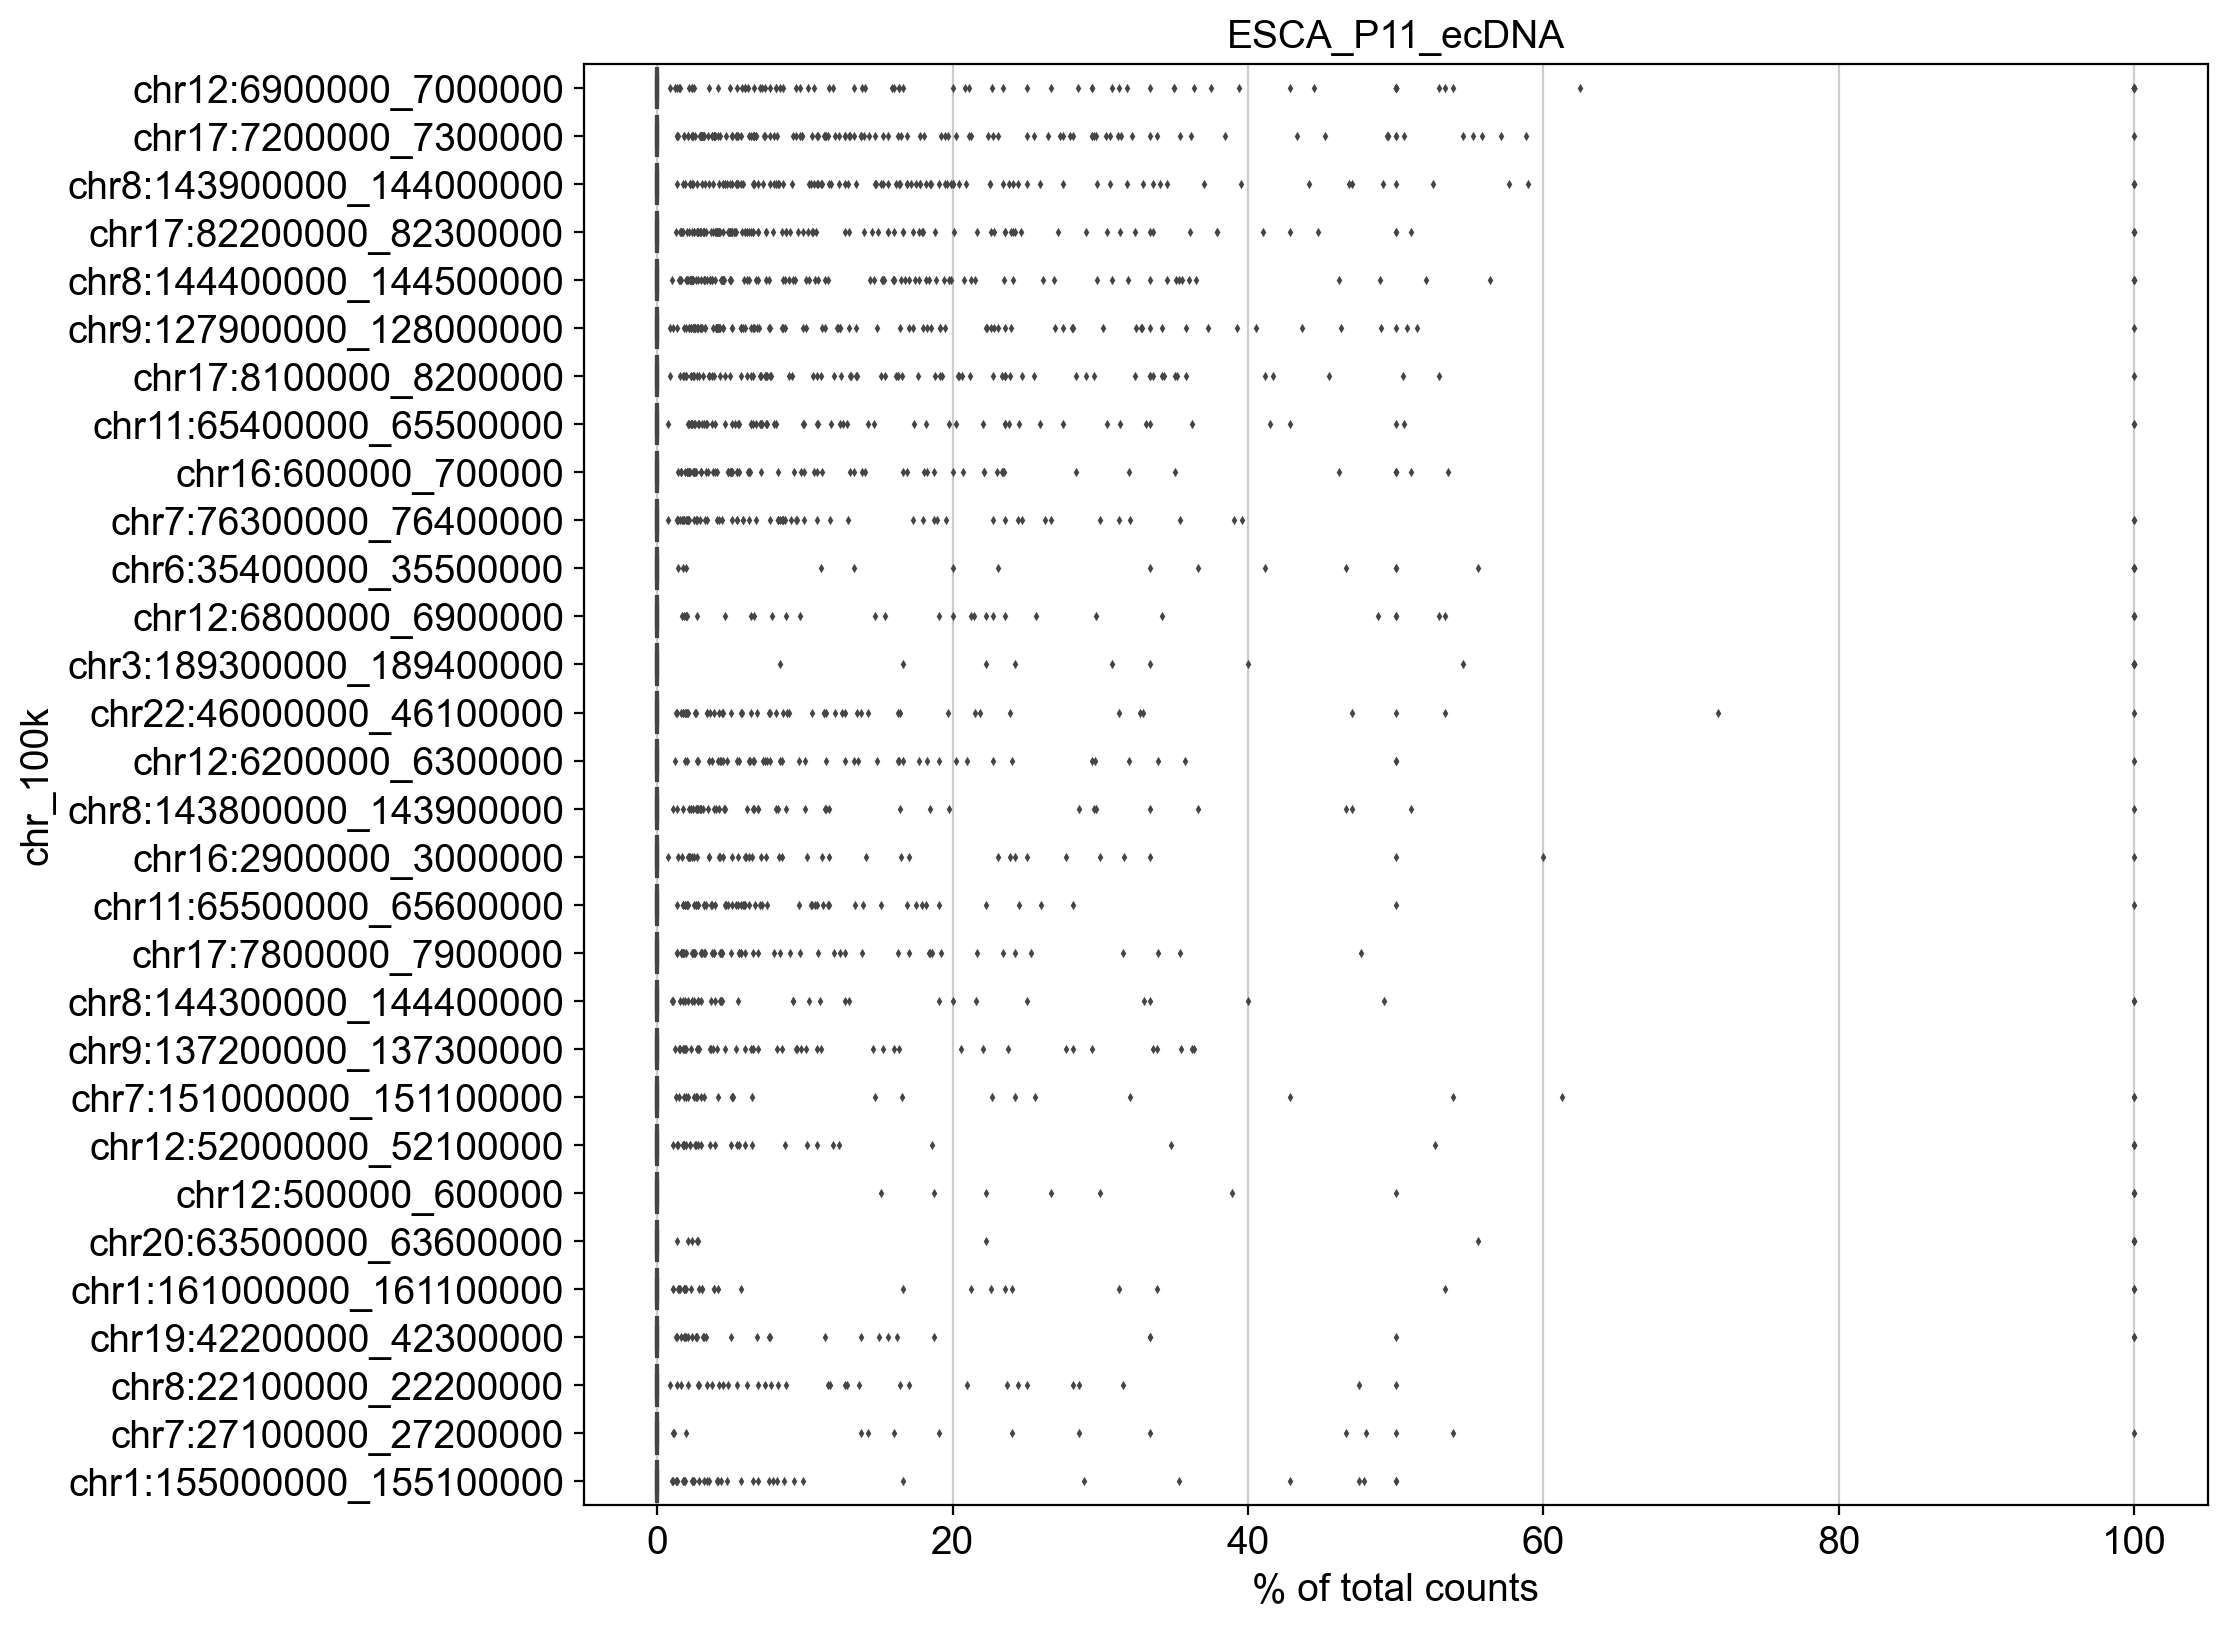

In [22]:
title = "ESCA_P11_ecDNA"
adata = adata_combined.copy()
# 过滤低质量细胞
sc.pp.filter_cells(adata, min_genes=1)
sc.pp.filter_genes(adata, min_cells=1)

# f01
fig, ax = plt.subplots(figsize=(16, 13))
sc.pl.highest_expr_genes(adata, n_top=30, ax=ax, show=False)
plt.title(title)
plt.tight_layout(pad=13.0)
fig.savefig(f"f01-highest_amplified_ecdna-nofbg.pdf", bbox_inches='tight')
plt.show()
plt.close(fig)

C:\Users\wangyuhang\AppData\Local\Temp\ipykernel_30048\601254383.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad=13.0)


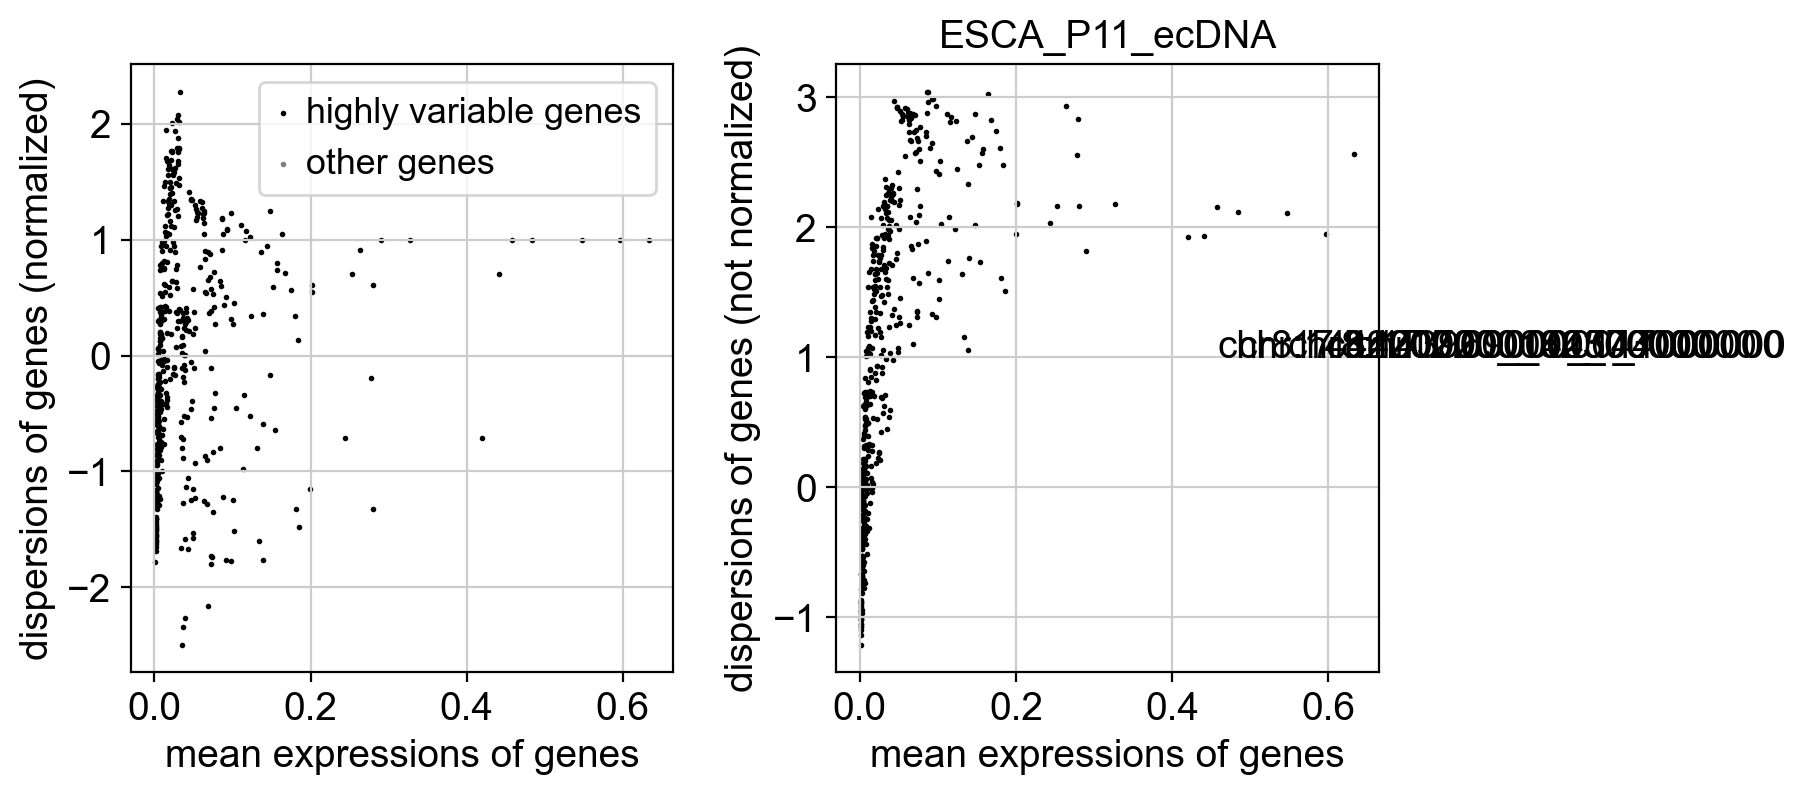

In [23]:
# calculate_qc_metrics
adata.var['chr8'] = adata.var_names.str.startswith('chr8') # annotate the group of chr19 ecdna_regions as 'chr19'
sc.pp.calculate_qc_metrics(adata, qc_vars=['chr8'], percent_top=None, log1p=False, inplace=True)
adata.obs["n_ecdna_regions"]=adata.obs["n_genes"]
adata.obs["total_coverages"]=adata.obs["total_counts"]
adata.obs["pct_coverages_chr8"]=adata.obs["pct_counts_chr8"]

# 标准化表达矩阵
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
#sc.pp.highly_variable_genes(adata, n_top_genes=10)
#sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=np.inf, min_disp=0.5)
sc.pp.highly_variable_genes(adata, min_mean=0.001, max_mean=np.inf, min_disp=-np.inf)

# 创建一个新的figure对象
#fig, ax = plt.subplots(figsize=(16, 16))
# 在这个figure对象上绘制图像
sc.pl.highly_variable_genes(adata, show=False)
# 获取高度可变基因的名字和坐标
hvg = adata.var[adata.var['highly_variable']]
hvg_sub = hvg.nlargest(5, 'means').copy()
for gene in hvg_sub.index:
    x = hvg_sub.loc[gene, 'means']
    y = hvg_sub.loc[gene, 'dispersions_norm']
    plt.annotate(gene, (x, y))
    pass
plt.title(title)
plt.tight_layout(pad=13.0)
# 保存图像为PDF文件
plt.savefig("f02-highly_variable_genes-nofbg.pdf", bbox_inches='tight')
plt.show()
plt.close(fig)

In [24]:
adata.raw = adata
#adata = adata[:, adata.var.highly_variable]

In [25]:
sc.pp.scale(adata)
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

In [28]:
adata_temp = adata.copy()
resolution_best = find_resolution(adata_temp, n_clusters=4) 
#resolution_best = 0.625
print("resolution_best: "+str(resolution_best))
sc.tl.leiden(adata, resolution=resolution_best)

resolution_best: 0.53125


In [29]:
from scipy.stats import entropy
grouped = adata.obs.copy()[["sample","leiden"]].groupby('sample')
for name, group in grouped:
    shannon_entropy = entropy(group['leiden'].value_counts(normalize=True))
    print(name,shannon_entropy)

P11_LN_N 0.9167255113873193
P11_LN_NR 0.27018681837789793
P11_LN_R 0.3273003458961691
P11_T_0 1.0852254705520343


In [30]:
# create a dictionary to map cluster to annotation label
leiden2abc = {"0": 'A', "1": 'B', "2": 'C', "3": 'D', "4": 'E', "5": 'F', "6": 'G', "7": 'H', "8": 'I', "9": 'J'}
adata.obs['leiden_type'] = adata.obs['leiden'].replace(leiden2abc)
unique_leiden_values = adata.obs['leiden_type'].unique()
cluster2annotation = {value: f'Clone_{value}' for value in unique_leiden_values}
# add a new `.obs` column called `cell type` by mapping clusters to annotation using pandas `map` function
adata.obs['clone_type'] = adata.obs['leiden_type'].map(cluster2annotation).astype('category')

C:\Users\wangyuhang\AppData\Local\Temp\ipykernel_30048\2241415788.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=13)
C:\Users\wangyuhang\AppData\Local\Temp\ipykernel_30048\2241415788.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad=13)


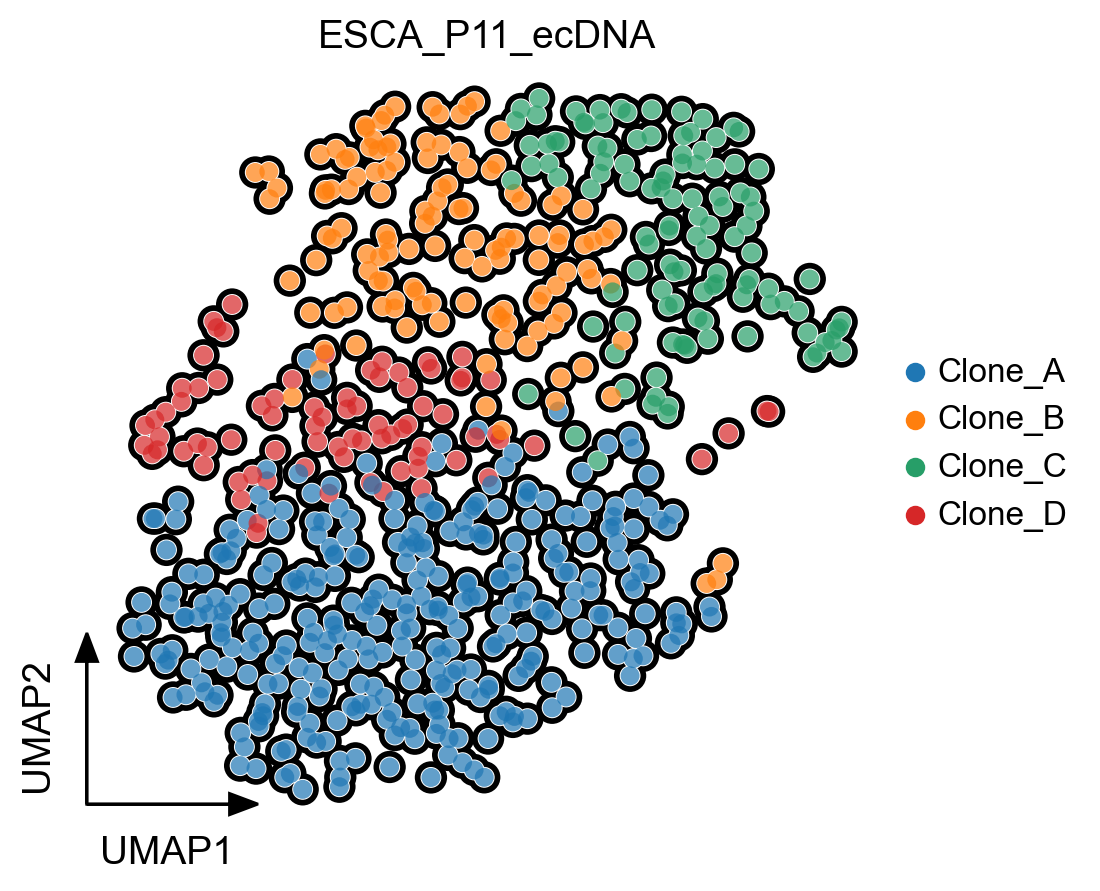

In [31]:
# 生成颜色列表
from matplotlib.colors import to_hex
hex_colors = [to_hex(color) for color in sns.color_palette()]
cancer_pal = sns.color_palette(hex_colors)
#cancer_pal[6],cancer_pal[16]

# f02
fig, ax = plt.subplots(figsize=(5, 5))
sc.pl.umap(adata, 
           color='clone_type', 
           add_outline=True, 
           #legend_loc='on data',
           legend_loc='right margin',
           legend_fontsize=12, 
           legend_fontoutline=2,
           frameon=False,
           ax=ax,
           show=False,
           title=title, 
           palette=cancer_pal)
#plt.title(str(lib_name))
# 添加迷你的xy坐标轴
mini_ax = fig.add_axes([0.15, 0.15, 0.2, 0.2], frame_on=False)  # 在左下角添加一个新的坐标轴，不显示边框
mini_ax.set_xticks([])  # 不显示x轴的刻度
mini_ax.set_yticks([])  # 不显示y轴的刻度
mini_ax.set_xlabel('UMAP1')  # 设置x轴的名称
mini_ax.set_ylabel('UMAP2')  # 设置y轴的名称
# 添加箭头
mini_ax.arrow(0, 0, 1, 0, head_width=0.15, head_length=0.2, fc='k', ec='k')
mini_ax.arrow(0, 0, 0, 1, head_width=0.15, head_length=0.2, fc='k', ec='k')
plt.tight_layout(pad=13)
fig.savefig("f03-cell_clustering-nofbg.pdf", bbox_inches='tight')

In [40]:
cancer_pal[4:]

[(0.6666666666666666, 0.25098039215686274, 0.9882352941176471),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.7098039215686275, 0.7411764705882353, 0.3803921568627451),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529),
 (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
 (1.0, 0.7333333333333333, 0.47058823529411764),
 (0.596078431372549, 0.8745098039215686, 0.5411764705882353),
 (1.0, 0.596078431372549, 0.5882352941176471),
 (0.7725490196078432, 0.6901960784313725, 0.8352941176470589),
 (0.7686274509803922, 0.611764705882353, 0.5803921568627451),
 (0.9686274509803922, 0.7137254901960784, 0.8235294117647058),
 (0.8588235294117647, 0.8588235294117647, 0.5529411764705883),
 (0.6196078431372549, 0.8549019607843137, 0.8980392156862745),
 (0.6784313725490196, 0.28627450980392155, 0.2901960784313726),
 (0.5490196078431373, 0.42745098039215684, 0.19215686274509805)]

C:\Users\wangyuhang\AppData\Local\Temp\ipykernel_30048\616009169.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=13)
C:\Users\wangyuhang\AppData\Local\Temp\ipykernel_30048\616009169.py:30: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad=13)


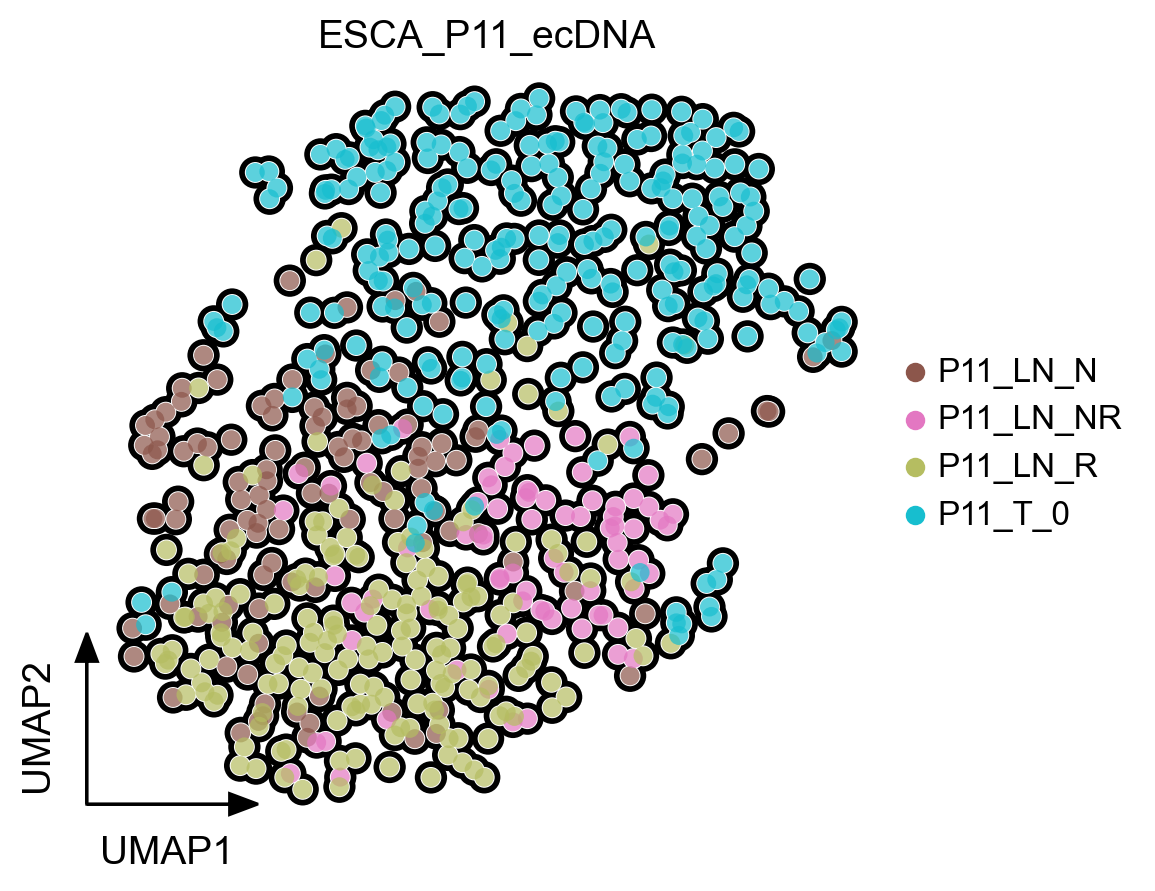

In [42]:
# 生成颜色列表
from matplotlib.colors import to_hex
hex_colors = [to_hex(color) for color in sns.color_palette()]
cancer_pal = sns.color_palette(hex_colors)

# f02
fig, ax = plt.subplots(figsize=(5, 5))
sc.pl.umap(adata, 
           color='sample', 
           add_outline=True, 
           #legend_loc='on data',
           legend_loc='right margin',
           legend_fontsize=12, 
           legend_fontoutline=2,
           frameon=False,
           ax=ax,
           show=False,
           title=title, 
           palette=cancer_pal[5:])
#plt.title(str(lib_name)) 
# 添加迷你的xy坐标轴
mini_ax = fig.add_axes([0.15, 0.15, 0.2, 0.2], frame_on=False)  # 在左下角添加一个新的坐标轴，不显示边框
mini_ax.set_xticks([])  # 不显示x轴的刻度
mini_ax.set_yticks([])  # 不显示y轴的刻度
mini_ax.set_xlabel('UMAP1')  # 设置x轴的名称
mini_ax.set_ylabel('UMAP2')  # 设置y轴的名称
# 添加箭头
mini_ax.arrow(0, 0, 1, 0, head_width=0.15, head_length=0.2, fc='k', ec='k')
mini_ax.arrow(0, 0, 0, 1, head_width=0.15, head_length=0.2, fc='k', ec='k')
plt.tight_layout(pad=13)
fig.savefig("f04-cell_clustering_pm-nofbg.pdf", bbox_inches='tight')

In [33]:
# 按照 cell_type 分组计算差异基因，给定基因排序
sc.tl.rank_genes_groups(adata, groupby='clone_type', method='wilcoxon')
# method::'t-test'/'t-test_overestim_var'/'wilcoxon'/'logreg'

C:\Users\wangyuhang\.conda\envs\py310\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
C:\Users\wangyuhang\.conda\envs\py310\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
C:\Users\wangyuhang\.conda\envs\py310\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
C:\Users\wangyuhang\.conda\envs\py310\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(


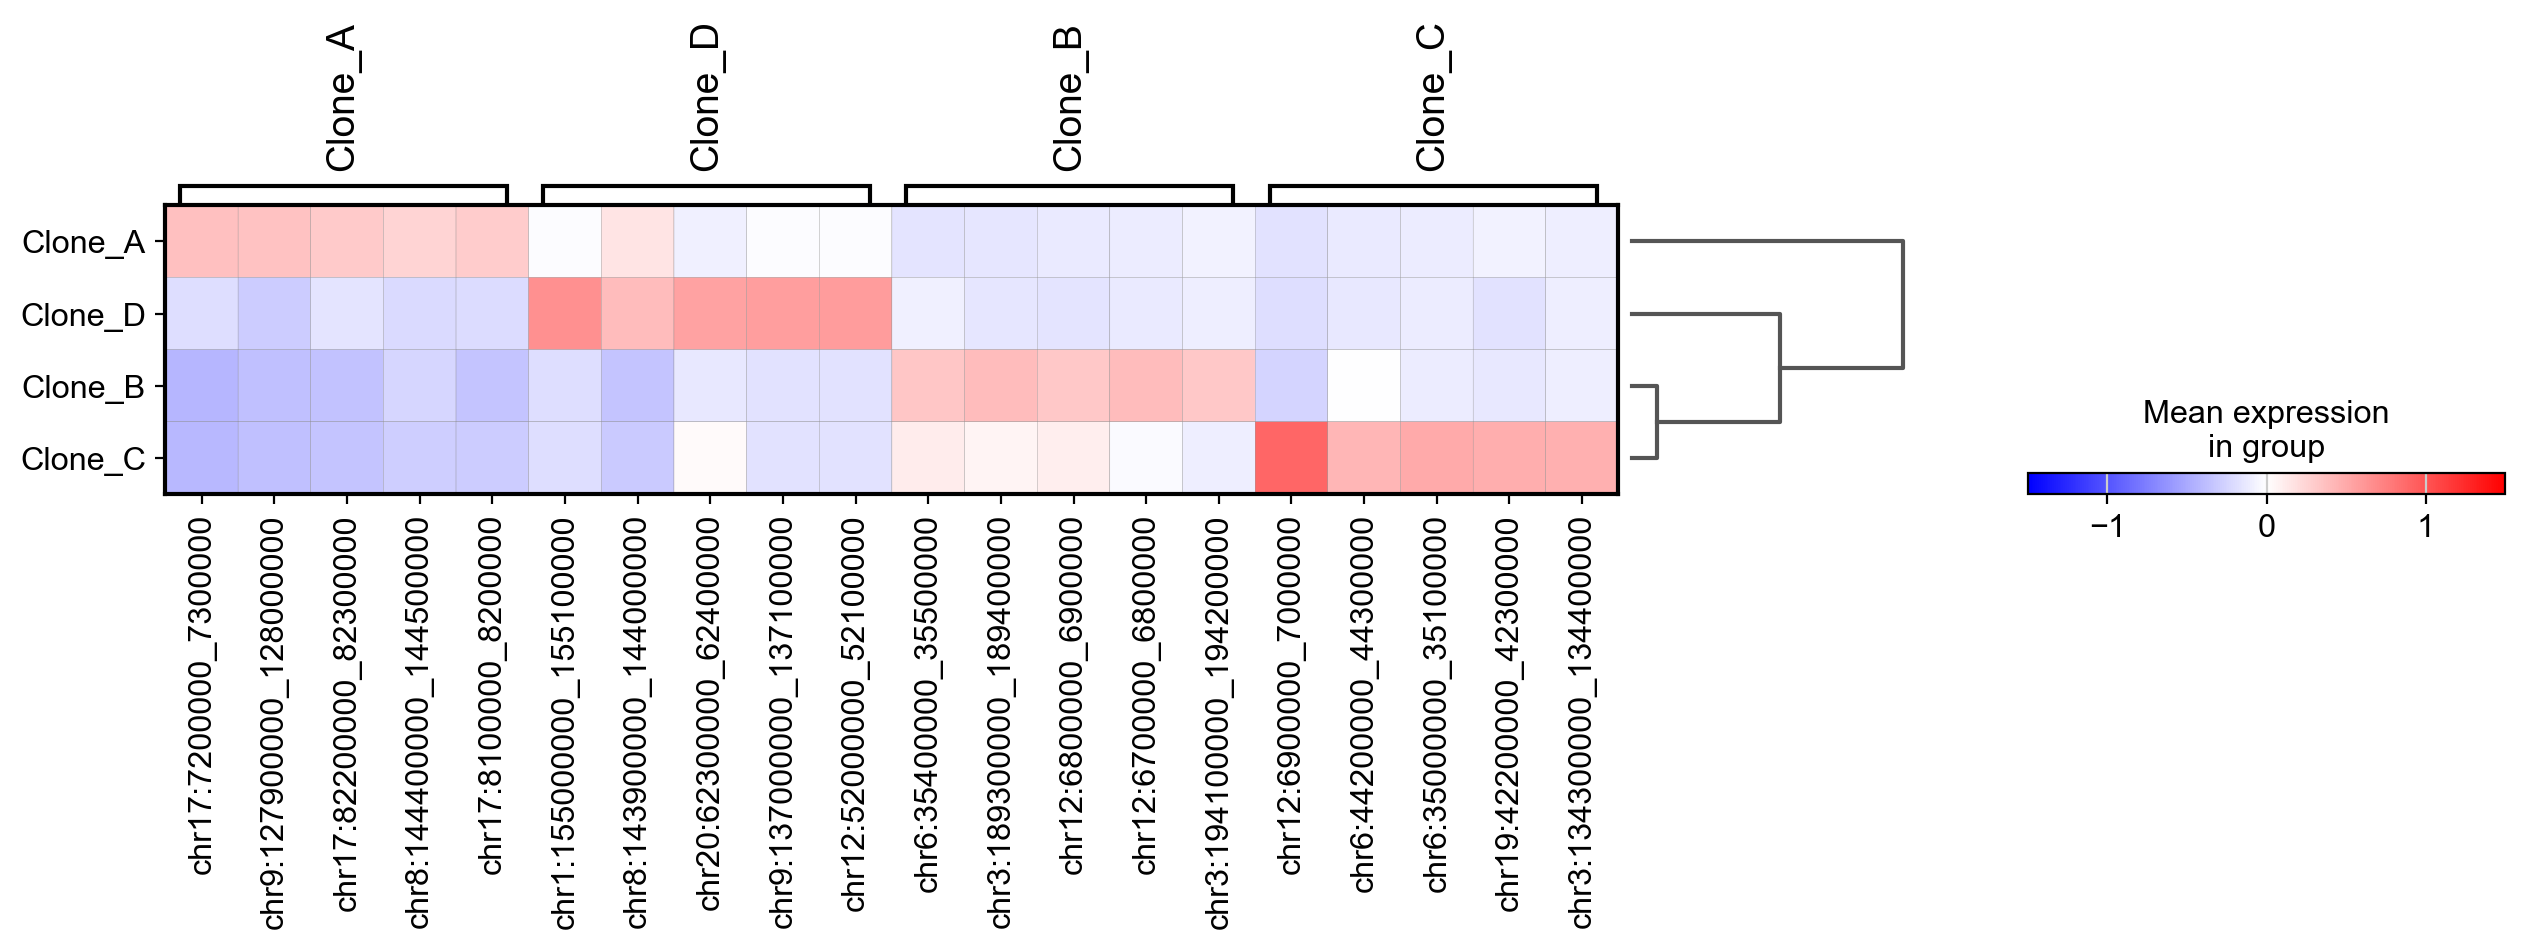

<Figure size 400x400 with 0 Axes>

In [34]:
fig, ax = plt.subplots(figsize=(15, 1.9))
sc.pl.rank_genes_groups_matrixplot(adata, n_genes=5, 
                                   use_raw=True, 
                                   vmin=-1.5, vmax=1.5, 
                                   ax=ax,
                                   cmap='bwr', 
                                   figsize=(7,1.6))
plt.tight_layout(pad=13.0)
fig.savefig("f05-square_list-nofbg.pdf", bbox_inches='tight')

In [35]:
# 按照 cell_type 分组计算差异基因，给定基因排序
sc.tl.rank_genes_groups(adata, groupby='sample', method='wilcoxon') 
# method::'t-test'/'t-test_overestim_var'/'wilcoxon'/'logreg'

C:\Users\wangyuhang\.conda\envs\py310\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
C:\Users\wangyuhang\.conda\envs\py310\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
C:\Users\wangyuhang\.conda\envs\py310\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
C:\Users\wangyuhang\.conda\envs\py310\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(


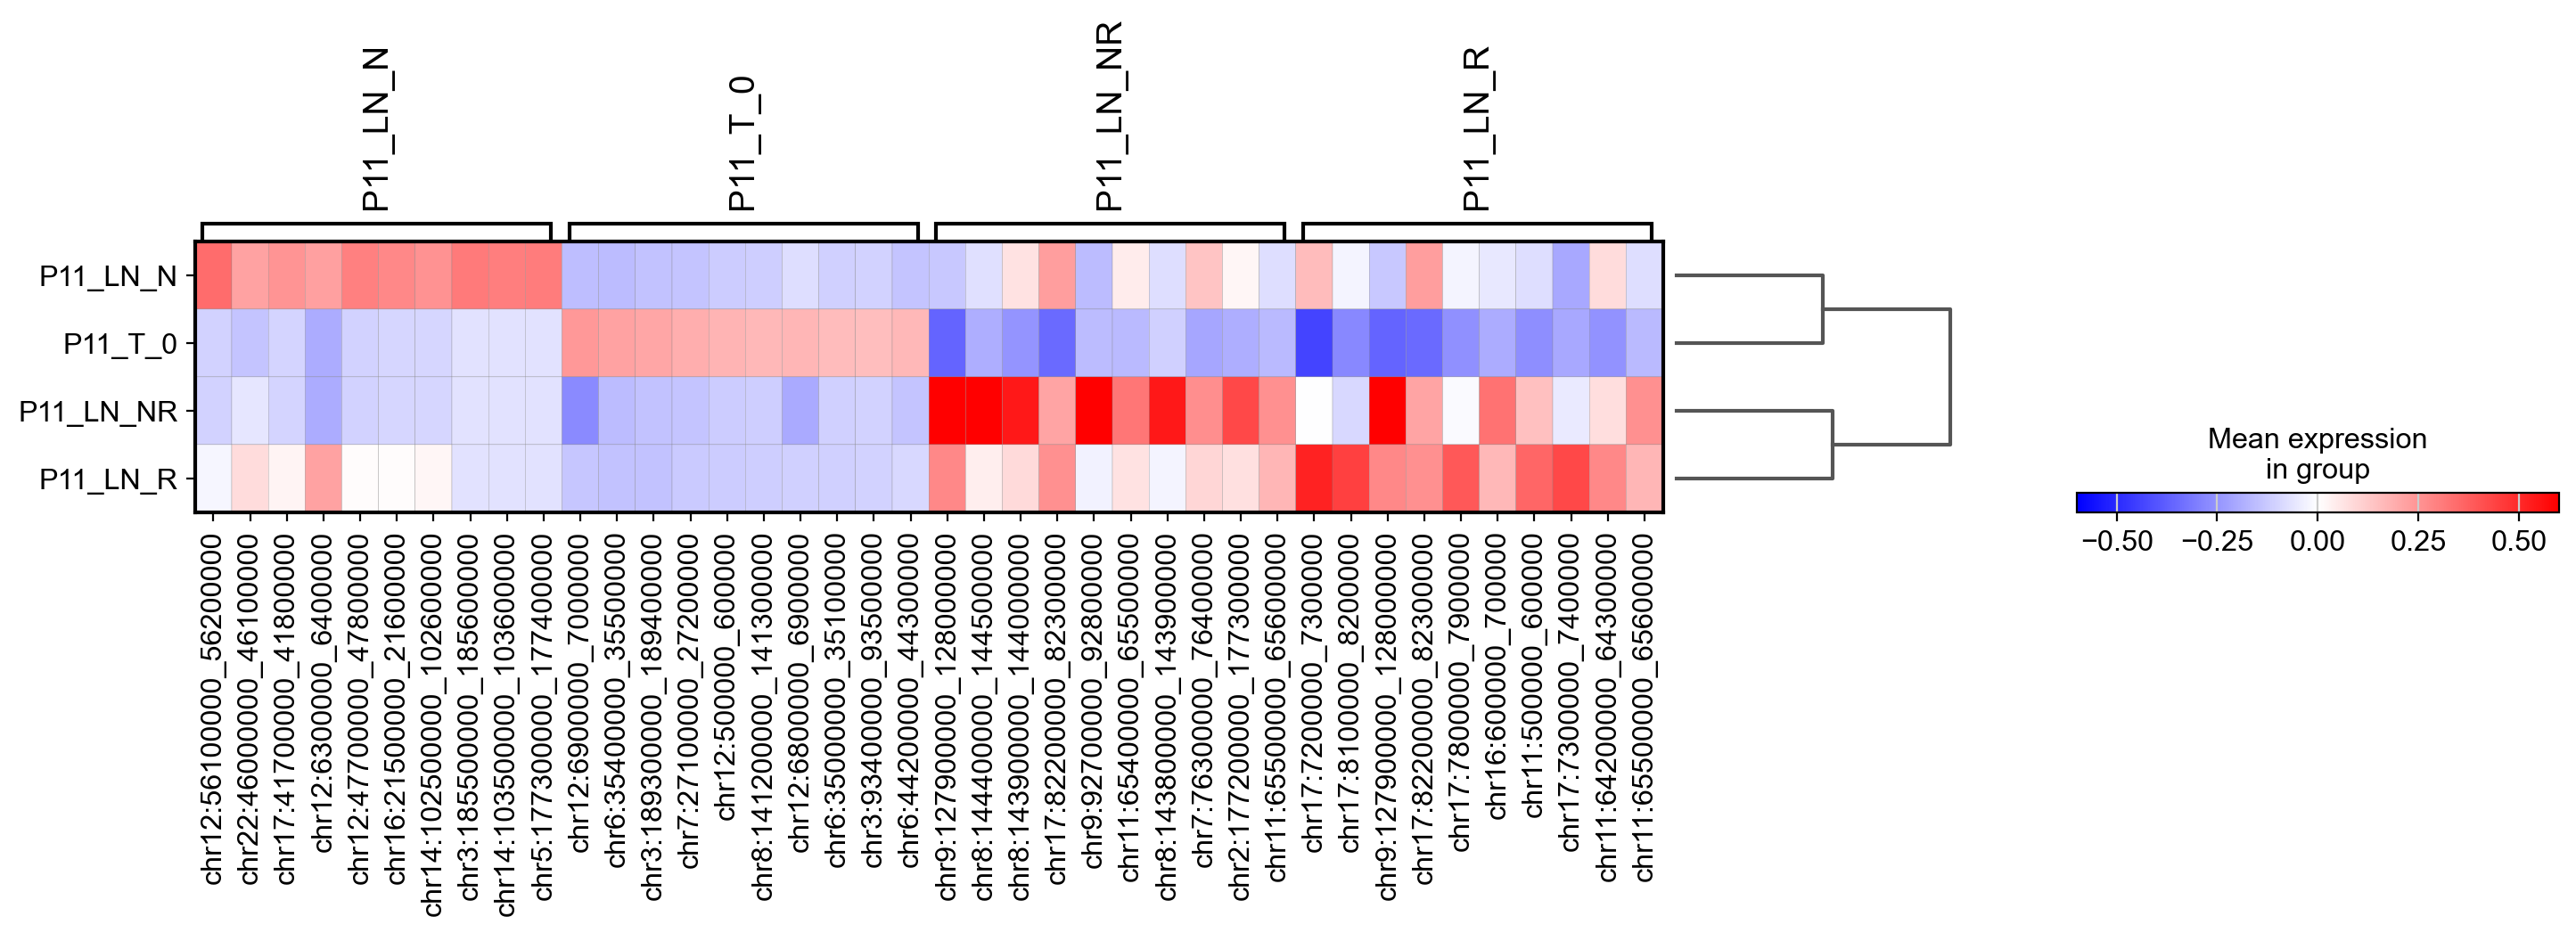

<Figure size 400x400 with 0 Axes>

In [36]:
fig, ax = plt.subplots(figsize=(17, 2))
sc.pl.rank_genes_groups_matrixplot(adata, n_genes=10, 
                                   use_raw=True, 
                                   vmin=-0.6, vmax=0.6, 
                                   ax=ax,
                                   cmap='bwr', 
                                   figsize=(7,1.6))
plt.tight_layout(pad=13.0)
fig.savefig("f06-square_list_pm-nofbg.pdf", bbox_inches='tight')

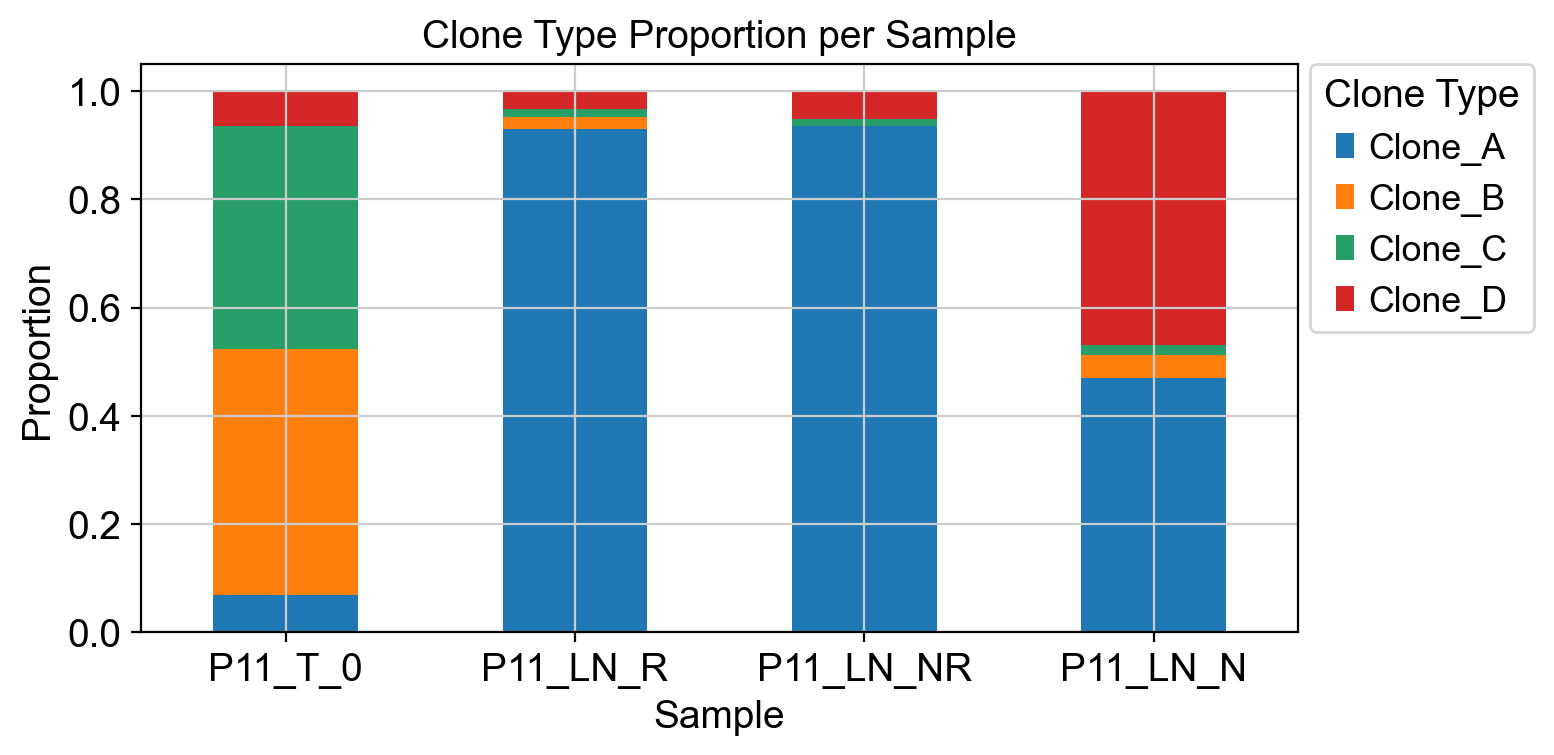

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# 示例 DataFrame（替换成你的实际数据）
df = adata.obs[["sample", "clone_type"]].copy()

# 1. 统计各 clone_type 在每个 sample 中的数量
count_df = df.groupby(['sample', 'clone_type']).size().unstack(fill_value=0)

# 2. 计算占比（按行归一化）
percent_df = count_df.div(count_df.sum(axis=1), axis=0)

# 3. 倒序排列 x 轴的 sample 标签
percent_df = percent_df[::-1]  # 或使用 percent_df.sort_index(ascending=False)

# 4. 画图
percent_df.plot(kind='bar', stacked=True, figsize=(8, 4))
plt.ylabel("Proportion")
plt.xlabel("Sample")
plt.title("Clone Type Proportion per Sample")
plt.xticks(rotation=0)
plt.legend(title='Clone Type', bbox_to_anchor=(1.01, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.savefig("f07-Clone_type_Proportion_per_Sample-nofbg.pdf", bbox_inches='tight')


In [74]:
# 计算基尼系数的函数
def gini(array):
    array = np.array(array)
    array = array.flatten()
    if np.amin(array) < 0:
        array -= np.amin(array)
    array += 0.0000001
    array = np.sort(array)
    index = np.arange(1, array.shape[0] + 1)
    n = array.shape[0]
    return ((np.sum((2 * index - n - 1) * array)) / (n * np.sum(array)))

In [77]:
df_tem = adata.obs.copy()[["sample_name","leiden"]]

all_results = pd.DataFrame(columns=['sample_name', 'Shannon_Entropy', 'Gini_Coefficient'])
for i in df_tem["sample_name"].unique():
    sample_name = i
    df1 = df_tem[df_tem["sample_name"]==i]['leiden'].value_counts(normalize=True)
    shannon_entropy = entropy(df1)
    gini_coefficient = gini(df1)
    results = []
    results.append([sample_name, shannon_entropy, gini_coefficient])
    # 创建新的 DataFrame 存储结果
    df2 = pd.DataFrame(results, columns=['sample_name', 'Shannon_Entropy', 'Gini_Coefficient'])
    # 将 df2 追加到 all_results
    all_results = pd.concat([all_results, df2], ignore_index=True)
    pass
all_results
# 步骤 1：添加 type 列
all_results["sample_type"] = ["Metastatic", "Metastatic", "Metastatic", "Primary"]
# 步骤 2：重复第4行两次并添加
df_extended = pd.concat([all_results, all_results.iloc[[3, 3]]], ignore_index=True)
# 步骤 3：添加 group 列（初始设为 sample_name）
df_extended["group"] = df_extended["sample_name"]
# 步骤 4：修改 group 列内容
df_extended["group"] = ["P11_LN_N", "P11_LN_NR", "P11_LN_R",
                        "P11_LN_N", "P11_LN_NR", "P11_LN_R"]
# 打印结果
print(df_extended)
df_extended.to_csv("f10-Shannon_Gini.tsv", sep='\t', index=False)


  sample_name  Shannon_Entropy  Gini_Coefficient sample_type      group
0    P11_LN_N         0.916726          0.445652  Metastatic   P11_LN_N
1   P11_LN_NR         0.270187          0.711538  Metastatic  P11_LN_NR
2    P11_LN_R         0.327300          0.688172  Metastatic   P11_LN_R
3     P11_T_0         1.085225          0.377862     Primary   P11_LN_N
4     P11_T_0         1.085225          0.377862     Primary  P11_LN_NR
5     P11_T_0         1.085225          0.377862     Primary   P11_LN_R


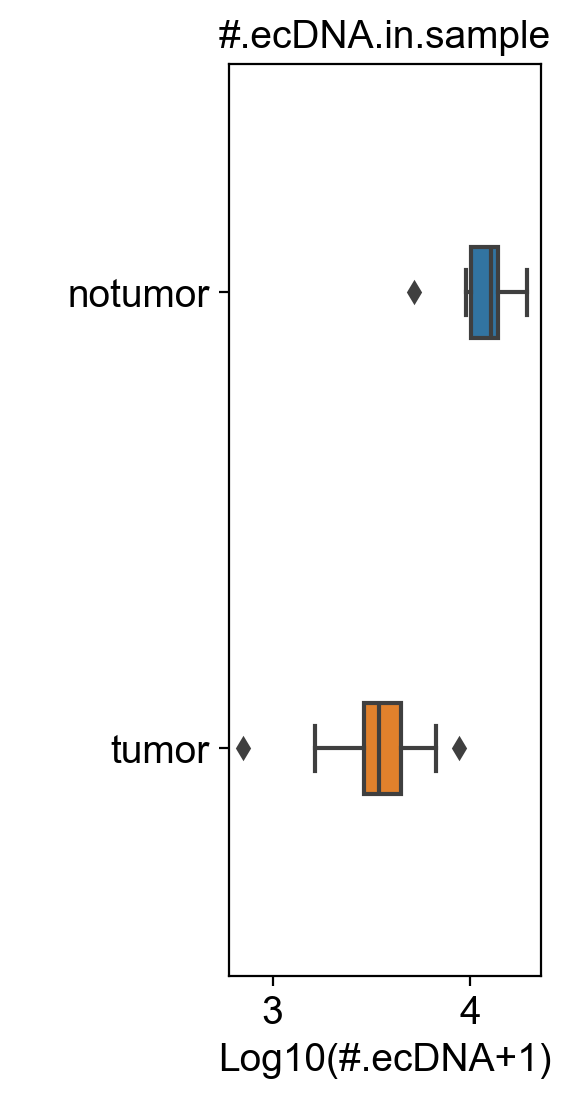

In [10]:
### 按照cancer merge
df = df_cancer_sample.copy()

# 获取所有的Sample_types
Sample_types = df['cancer'].unique()
# 对每一对Sample_types类型进行差异检验，并保存 统计量和 p 值
stats = []
p_values = {}
for i in range(len(Sample_types)):
    type1 = Sample_types[i]
    data1 = df[df['cancer'] == type1]['log10_ecDNA_count']
    data2 = df[df['cancer'] != type1]['log10_ecDNA_count']
    t_stat, t_stat_p_val = ttest_ind(data1, data2) # t检验
    u_stat, u_stat_p_val = mannwhitneyu(data1, data2) # 秩和检验
    ks_stat, ks_stat_p_val = ks_2samp(data1, data2) # Kolmogorov-Smirnov 检验
    p_values[type1] = t_stat_p_val
    stats.append((type1, t_stat, t_stat_p_val, u_stat, u_stat_p_val, ks_stat, ks_stat_p_val))
# 将结果整理为数据框
df_stats = pd.DataFrame(stats, columns=['sample', 't_stat', 't_stat_p_val', 'u_stat', 'u_stat_p_val', 'ks_stat', 'ks_stat_p_val'])
#df_stats.to_csv(f"./fig_100k_merge_3/stat_cov3/f01-df_cancer_sample-log10_ecDNA_count-p_values.tsv", sep='\t', index=False)

# 根据样本数量确定图形宽度
width = max(len(df['cancer'].unique()) * 0.25,5)
# 绘制小提琴图
plt.figure(figsize=(2, 6))  # 调整图形的大小
sns.boxplot(y='cancer', x='log10_ecDNA_count', data=df, width=0.2, showfliers=True)
# 添加 p 值注释
for i, type1 in enumerate(Sample_types):
    p_val = p_values[type1]
    if p_val < 0.001:
        p_text = '***'
    elif p_val < 0.01:
        p_text = '**'
    elif p_val < 0.05:
        p_text = '*'
    else:
        p_text = 'ns'
    #plt.text(3.9, i, p_text, ha='center')
#plt.xlim(2.9,4)
#plt.xticks(np.arange(3, 4, 0.3))  # 设置 y 轴的刻度标签
plt.ylabel(' ')
plt.xlabel('Log10(#.ecDNA+1)')
plt.title('#.ecDNA.in.sample')
#plt.xticks(rotation=45) # 将x轴的标签更改为倾斜字体
#plt.legend(title='Cancer Type')  # 添加图例标题
#plt.legend(bbox_to_anchor=(1.01, 1), loc=2, borderaxespad=0.)
plt.grid(False)  # 关闭网格线
#plt.show()
# 保存图形为PDF文件
#plt.savefig(f"./fig_100k_merge_3/stat_cov3/f01-df_cancer_sample-log10_ecDNA_count_boxplot.pdf", bbox_inches='tight')

In [11]:
##### in cell
from scipy.stats import ttest_ind,mannwhitneyu,ks_2samp

In [12]:
from scipy.stats import ttest_ind,mannwhitneyu,ks_2samp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 统计coverage>=6的ecDNA数量
df_cancer_sample_cell = pd.DataFrame(columns=["cancer", 'sample', "cell", 'ecDNA_count'])
# 从 adata_list 对象 adata_sample 中提取每种癌症类型的每个样本的ecDNA数量
for adata_sample in adata_list:
    plot_data = []
    adata_sample = adata_sample.copy()
    cancer = adata_sample.obs["NT"].to_list()[0]
    sample = adata_sample.obs["sample"].to_list()[0]
    
    # 将adata.X中 NaN值替换为0值
    #adata_sample.X = np.nan_to_num(adata_sample.X)
    # 将adata.X中 max_coverage
    #adata_sample.var['max_coverage'] = adata_sample.X.max(axis=0)
    #adata_sample = adata_sample[:, adata_sample.var['max_coverage'] >= 6].copy()
    for cell in range(adata_sample.shape[0]):
        # 计算该细胞的ecDNA cov>=3 数量
        ecDNA_count = np.sum(adata_sample.X[cell, :] > 0)
        ecDNA_count_cov0 = np.sum(adata_sample.X[cell, :] > 0)
        ecDNA_count_cov3 = np.sum(adata_sample.X[cell, :] >= 3)
        ecDNA_count_cov4 = np.sum(adata_sample.X[cell, :] >= 4)
        ecDNA_count_cov5 = np.sum(adata_sample.X[cell, :] >= 5)
        ecDNA_count_cov6 = np.sum(adata_sample.X[cell, :] >= 6)
        plot_data.append((cancer, sample, cell, ecDNA_count,ecDNA_count_cov0,ecDNA_count_cov3,ecDNA_count_cov4,ecDNA_count_cov5,ecDNA_count_cov6))
        pass
    
    # 转换为DataFrame
    df_temp = pd.DataFrame(plot_data, columns=["cancer",'sample',
                                               "cell",'ecDNA_count',
                                               "ecDNA_count_cov0",
                                               "ecDNA_count_cov3","ecDNA_count_cov4",
                                               "ecDNA_count_cov5","ecDNA_count_cov6"])
    df_cancer_sample_cell = pd.concat([df_cancer_sample_cell, df_temp])
    pass
df_cancer_sample_cell = df_cancer_sample_cell.sort_values(by=["cancer","sample","cell"])
#df_cancer_sample_cell.to_csv('./fig_100k_merge_3/stat_cov3/f02-df_cancer_sample_cell.tsv', sep='\t', index=False)
df_cancer_sample_cell

,cancer,sample,cell,ecDNA_count,ecDNA_count_cov0,ecDNA_count_cov3,ecDNA_count_cov4,ecDNA_count_cov5,ecDNA_count_cov6
0,notumor,P07_T_0_NT,0,6338,6338.0,168.0,43.0,10.0,3.0
1,notumor,P07_T_0_NT,1,4412,4412.0,477.0,183.0,84.0,44.0
2,notumor,P07_T_0_NT,2,7656,7656.0,84.0,16.0,5.0,1.0
3,notumor,P07_T_0_NT,3,3202,3202.0,786.0,249.0,249.0,95.0
4,notumor,P07_T_0_NT,4,3541,3541.0,457.0,457.0,231.0,136.0
...,...,...,...,...,...,...,...,...,...
85,tumor,Z3_K27_T_A_SC2,85,1233,1233.0,16.0,6.0,3.0,3.0
86,tumor,Z3_K27_T_A_SC2,86,683,683.0,240.0,193.0,165.0,146.0
87,tumor,Z3_K27_T_A_SC2,87,716,716.0,168.0,91.0,89.0,68.0
88,tumor,Z3_K27_T_A_SC2,88,988,988.0,112.0,108.0,59.0,36.0


In [13]:
#df_cancer_sample_cell = pd.read_csv('./fig_100k_merge_3/stat_cov3/f02-df_cancer_sample_cell.tsv', sep='\t')
df_cancer_sample_cell

,cancer,sample,cell,ecDNA_count,ecDNA_count_cov0,ecDNA_count_cov3,ecDNA_count_cov4,ecDNA_count_cov5,ecDNA_count_cov6
0,notumor,P07_T_0_NT,0,6338,6338.0,168.0,43.0,10.0,3.0
1,notumor,P07_T_0_NT,1,4412,4412.0,477.0,183.0,84.0,44.0
2,notumor,P07_T_0_NT,2,7656,7656.0,84.0,16.0,5.0,1.0
3,notumor,P07_T_0_NT,3,3202,3202.0,786.0,249.0,249.0,95.0
4,notumor,P07_T_0_NT,4,3541,3541.0,457.0,457.0,231.0,136.0
...,...,...,...,...,...,...,...,...,...
85,tumor,Z3_K27_T_A_SC2,85,1233,1233.0,16.0,6.0,3.0,3.0
86,tumor,Z3_K27_T_A_SC2,86,683,683.0,240.0,193.0,165.0,146.0
87,tumor,Z3_K27_T_A_SC2,87,716,716.0,168.0,91.0,89.0,68.0
88,tumor,Z3_K27_T_A_SC2,88,988,988.0,112.0,108.0,59.0,36.0


In [14]:
df_cancer_sample_cell['log2_ecDNA_count_cov3'] = np.log2(df_cancer_sample_cell['ecDNA_count_cov3']+1)
df_cancer_sample_cell['log2_ecDNA_count_cov4'] = np.log2(df_cancer_sample_cell['ecDNA_count_cov4']+1)
df_cancer_sample_cell['log2_ecDNA_count_cov5'] = np.log2(df_cancer_sample_cell['ecDNA_count_cov5']+1)
df_cancer_sample_cell['log2_ecDNA_count_cov6'] = np.log2(df_cancer_sample_cell['ecDNA_count_cov6']+1)

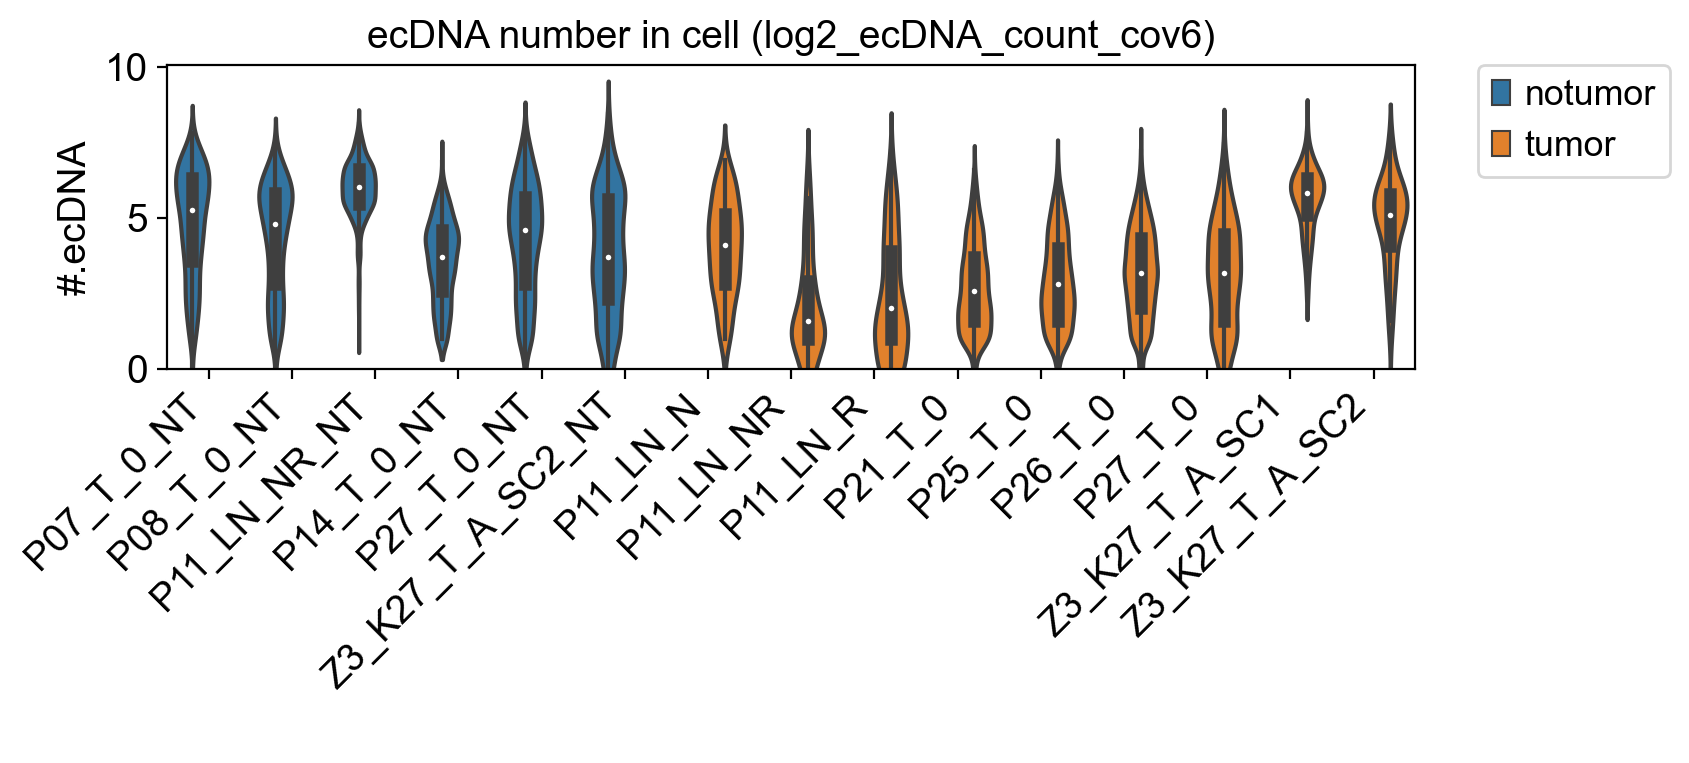

In [21]:
ylabel = "log2_ecDNA_count_cov6"

# 创建图形
# 根据样本数量确定图形宽度
width = max(2, (len(df_cancer_sample_cell['sample'].unique())+1) * 0.5)
# 绘制小提琴图
plt.figure(figsize=(width, 2))  # 调整图形的大小
sns.violinplot(x='sample', y=ylabel, data=df_cancer_sample_cell, scale="width",hue="cancer")
#sns.boxplot(x='Sample', y='log2_ecdna_count',data=df, width=0.2, showfliers=False)
#sns.stripplot(x='Sample', y='log2_ecdna_count', data=df, color="0.05",size=4)
plt.ylim(0)
#plt.yticks(np.arange(0, 10, 2))  # 设置 y 轴的刻度标签
plt.xlabel(' ')
plt.ylabel('#.ecDNA')
#plt.ylabel('#.ecDNA')
plt.title(f'ecDNA number in cell ({ylabel})')
plt.xticks(rotation=45,ha="right") # 将x轴的标签更改为倾斜字体
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.grid(False)  # 关闭网格线

In [29]:
from scipy.stats import ttest_ind,mannwhitneyu,ks_2samp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 统计coverage>=6的ecDNA数量
df_cancer_sample_cell = pd.DataFrame(columns=["cancer", 'sample', "ecdna", 'cell_count_cov3'])
# 从 adata_list 对象 adata_sample 中提取每种癌症类型的每个样本的ecDNA数量
for adata_sample in adata_list:
    plot_data = []
    adata_sample = adata_sample.copy()
    cancer = adata_sample.obs["NT"].to_list()[0]
    sample = adata_sample.obs["sample"].to_list()[0]
    
    # 将adata.X中 NaN值替换为0值
    #adata_sample.X = np.nan_to_num(adata_sample.X)
    # 将adata.X中 max_coverage
    #adata_sample.var['max_coverage'] = adata_sample.X.max(axis=0)
    #adata_sample = adata_sample[:, adata_sample.var['max_coverage'] >= 6].copy()
    for ecdna in range(adata_sample.shape[1]):
        # 计算该细胞的ecDNA cov>=3 数量
        cell_count_cov3 = np.sum(adata_sample.X[:,ecdna] >= 3)
        ecDNA_max_coverage = np.max(adata_sample.X[:,ecdna])
        plot_data.append((cancer, sample, ecdna, cell_count_cov3,ecDNA_max_coverage))
        pass
    
    # 转换为DataFrame
    df_temp = pd.DataFrame(plot_data, columns=["cancer",'sample',
                                               "ecdna",'cell_count_cov3',
                                               "ecDNA_max_coverage"])
    df_cancer_sample_cell = pd.concat([df_cancer_sample_cell, df_temp])
    pass
df_cancer_sample_cell = df_cancer_sample_cell.sort_values(by=["cancer","sample","ecdna"])
#df_cancer_sample_cell.to_csv('./fig_100k_merge_3/stat_cov3/f02-df_cancer_sample_cell.tsv', sep='\t', index=False)
df_cancer_sample_cell

,cancer,sample,ecdna,cell_count_cov3,ecDNA_max_coverage
0,notumor,P07_T_0_NT,0,65,6.513597
1,notumor,P07_T_0_NT,1,75,10.732904
2,notumor,P07_T_0_NT,2,40,7.478313
3,notumor,P07_T_0_NT,3,67,8.960573
4,notumor,P07_T_0_NT,4,103,7.949126
...,...,...,...,...,...
3287,tumor,Z3_K27_T_A_SC2,3287,1,6.692320
3288,tumor,Z3_K27_T_A_SC2,3288,3,8.662696
3289,tumor,Z3_K27_T_A_SC2,3289,1,5.226921
3290,tumor,Z3_K27_T_A_SC2,3290,4,14.147910


In [31]:
#df_cancer_sample_cell['log2_cell_count_cov3'] = np.log2(df_cancer_sample_cell['cell_count_cov3']+1)
df_cancer_sample_cell['log2_ecDNA_max_coverage'] = np.log2(df_cancer_sample_cell['ecDNA_max_coverage']+1)
df_cancer_sample_cell

,cancer,sample,ecdna,cell_count_cov3,ecDNA_max_coverage,log2_ecDNA_max_coverage
0,notumor,P07_T_0_NT,0,65,6.513597,2.909504
1,notumor,P07_T_0_NT,1,75,10.732904,3.552488
2,notumor,P07_T_0_NT,2,40,7.478313,3.083777
3,notumor,P07_T_0_NT,3,67,8.960573,3.316229
4,notumor,P07_T_0_NT,4,103,7.949126,3.161747
...,...,...,...,...,...,...
3287,tumor,Z3_K27_T_A_SC2,3287,1,6.692320,2.943419
3288,tumor,Z3_K27_T_A_SC2,3288,3,8.662696,3.272426
3289,tumor,Z3_K27_T_A_SC2,3289,1,5.226921,2.638519
3290,tumor,Z3_K27_T_A_SC2,3290,4,14.147910,3.921047


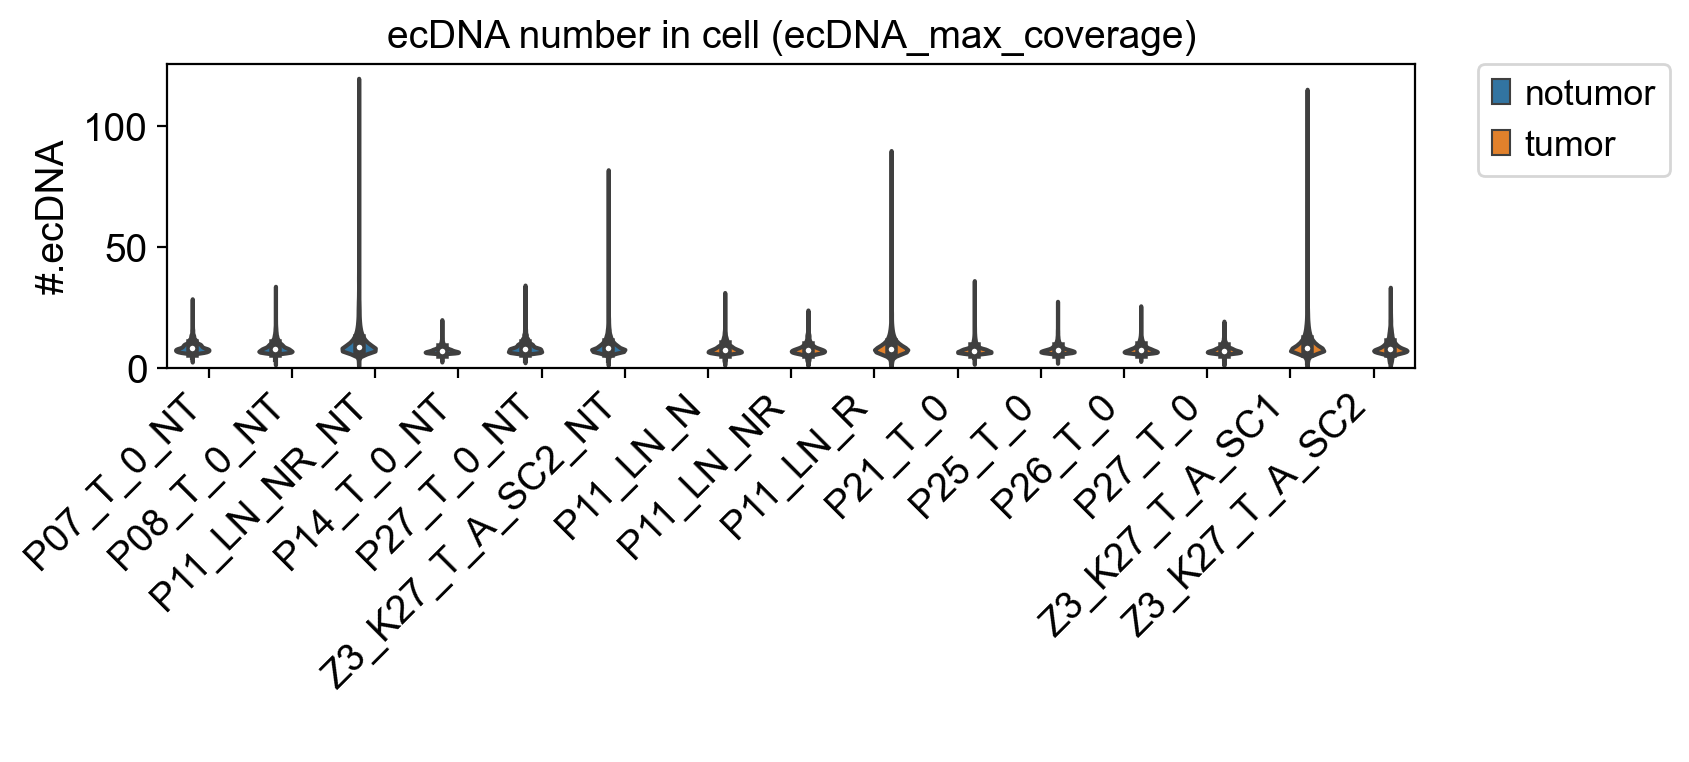

In [33]:
ylabel = "ecDNA_max_coverage"

# 创建图形
# 根据样本数量确定图形宽度
width = max(2, (len(df_cancer_sample_cell['sample'].unique())+1) * 0.5)
# 绘制小提琴图
plt.figure(figsize=(width, 2))  # 调整图形的大小
sns.violinplot(x='sample', y=ylabel, data=df_cancer_sample_cell, scale="width",hue="cancer")
#sns.boxplot(x='Sample', y='log2_ecdna_count',data=df, width=0.2, showfliers=False)
#sns.stripplot(x='Sample', y='log2_ecdna_count', data=df, color="0.05",size=4)
plt.ylim(0)
#plt.yticks(np.arange(0, 10, 2))  # 设置 y 轴的刻度标签
plt.xlabel(' ')
plt.ylabel('#.ecDNA')
#plt.ylabel('#.ecDNA')
plt.title(f'ecDNA number in cell ({ylabel})')
plt.xticks(rotation=45,ha="right") # 将x轴的标签更改为倾斜字体
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.grid(False)  # 关闭网格线

In [ ]:
df_cancer_sample_cell

In [34]:
df_cancer_sample_cell

,cancer,sample,ecdna,cell_count_cov3,ecDNA_max_coverage,log2_ecDNA_max_coverage
0,notumor,P07_T_0_NT,0,65,6.513597,2.909504
1,notumor,P07_T_0_NT,1,75,10.732904,3.552488
2,notumor,P07_T_0_NT,2,40,7.478313,3.083777
3,notumor,P07_T_0_NT,3,67,8.960573,3.316229
4,notumor,P07_T_0_NT,4,103,7.949126,3.161747
...,...,...,...,...,...,...
3287,tumor,Z3_K27_T_A_SC2,3287,1,6.692320,2.943419
3288,tumor,Z3_K27_T_A_SC2,3288,3,8.662696,3.272426
3289,tumor,Z3_K27_T_A_SC2,3289,1,5.226921,2.638519
3290,tumor,Z3_K27_T_A_SC2,3290,4,14.147910,3.921047


In [42]:
import matplotlib.pyplot as plt
import anndata as ad

def sample_ecdna_sum(adata: ad.AnnData, sample: str):
    """函数文档字符串"""
    # 函数代码块
    unit = 1000000
    adata = adata.copy()

    # 使用 np.nansum()
    sum_nansum = (np.nansum(adata.X, axis=0))/(adata.shape[0])
    
    # 创建一个字典来存储每个单元的覆盖度
    coverage_counts = {}
    for ecdna, coverage in zip(adata.var.index, sum_nansum):
        chr_name, region = ecdna.split(':')
        start, end = map(int, region.split('_'))
        unit_start = start // unit * unit
        unit_end = unit_start + unit
        unit_name = f'{chr_name}:{unit_start}_{unit_end}'
        #unit_name = f'{chr_name}:{unit_start}'
        if unit_name not in coverage_counts:
            coverage_counts[unit_name] = 0
        coverage_counts[unit_name] += coverage
    
    # 创建一个列表来存储单元的名称和覆盖度
    unit_names = list(coverage_counts.keys())
    coverages = list(coverage_counts.values())
    
    # 创建一个新的列表，其中包含 (unit_name, coverage) 对
    unit_coverage_pairs = list(zip(unit_names, coverages))
    # 创建一个字典，其中包含单元名称和覆盖度
    data = {'Chromsome_Unit': [], sample: []}
    for i,j in unit_coverage_pairs:
        data['Chromsome_Unit'].append(i)
        data[sample].append(j)
        pass
    
    # 创建 Pandas DataFrame
    df = pd.DataFrame(data).T
    # 获取指定行的元素作为新的列名
    new_columns = df.loc["Chromsome_Unit",:].tolist()
    # 替换DataFrame的列名
    df.columns = new_columns
    df = df.drop(index="Chromsome_Unit")
    return df

In [43]:
import matplotlib.pyplot as plt
import anndata as ad

def unit_coverage_pairs(adata: ad.AnnData,unit = 10000000):
    """函数文档字符串"""
    # 函数代码块
    unit = unit
    adata = adata.copy()

    # 使用 np.nansum()
    sum_nansum = (np.nansum(adata.X, axis=0))/(adata.shape[0])  #平均覆盖度coverage
    
    # 创建一个字典来存储每个单元的覆盖度
    coverage_counts = {}
    for ecdna, coverage in zip(adata.var.index, sum_nansum):
        chr_name, region = ecdna.split(':')
        start, end = map(int, region.split('_'))
        unit_start = start // unit * unit
        unit_end = unit_start + unit
        unit_name = f'{chr_name}:{unit_start}_{unit_end}'
        #unit_name = f'{chr_name}'
        if unit_name not in coverage_counts:
            coverage_counts[unit_name] = 0
        coverage_counts[unit_name] += coverage
    
    # 创建一个列表来存储单元的名称和覆盖度
    unit_names = list(coverage_counts.keys())
    coverages = list(coverage_counts.values())
    
    ### 按照chr序号排序
    # 创建一个新的列表，其中包含 (unit_name, coverage) 对
    unit_coverage_pairs = list(zip(unit_names, coverages))
    # 对列表进行排序，排序的关键字是 unit_name
    #unit_coverage_pairs.sort(key=lambda pair: (int(pair[0].split(':')[0][3:]), int(pair[0].split(':')[1].split('_')[0])))
    unit_coverage_pairs.sort(key=lambda pair: (int(pair[0].split(':')[0][3:]) if pair[0].split(':')[0][3:].isdigit() else {'X':23,'Y':24}.get(pair[0].split(':')[0][3:]),
                                               int(pair[0].split(':')[1].split('_')[0])))
    # 从排序后的列表中获取排序后的 unit_names 和 coverages
    #sorted_unit_names, sorted_coverages = zip(*unit_coverage_pairs)
    return unit_coverage_pairs

def unit_coverage_pairs_chr(adata: ad.AnnData):
    """函数文档字符串"""
    # 函数代码块
    adata = adata.copy()
    chromosome_lengths = {
        "chr1": 248956422,"chr2": 242193529,"chr3": 198295559,"chr4": 190214555,"chr5": 181538259,"chr6": 170805979,
        "chr7": 159345973,"chr8": 145138636,"chr9": 138394717,"chr10": 133797422,"chr11": 135086622,"chr12": 133275309,
        "chr13": 114364328,"chr14": 107043718,"chr15": 101991189,"chr16": 90338345,"chr17": 83257441,"chr18": 80373285,
        "chr19": 58617616,"chr20": 64444167,"chr21": 46709983,"chr22": 50818468,"chrX": 156040895,"chrY": 57227415,
    }
    # 使用 np.nansum()
    sum_nansum = (np.nansum(adata.X, axis=0))/(adata.shape[0])  #平均覆盖度coverage
    
    # 创建一个字典来存储每个chr的覆盖度
    coverage_counts = {}
    for ecdna, coverage in zip(adata.var.index, sum_nansum):
        chr_name, region = ecdna.split(':')
        unit_name = f'{chr_name}'
        if unit_name not in coverage_counts:
            coverage_counts[unit_name] = 0
        coverage_counts[unit_name] += coverage
    
    # 创建一个列表来存储单元的名称和覆盖度
    unit_names = list(coverage_counts.keys())
    coverages = list(coverage_counts.values())
    
    ### 按照chr序号排序
    # 创建一个新的列表，其中包含 (unit_name, coverage) 对
    unit_coverage_pairs = list(zip(unit_names, coverages))
    # 对列表进行排序，排序的关键字是 unit_name
    unit_coverage_pairs.sort(key=lambda pair: (int(pair[0][3:]) if pair[0][3:].isdigit() else {'X':23,'Y':24}.get(pair[0][3:])))

    # 创建一个新的列表来存储 (unit_name, normalized_coverage) 对
    normalized_unit_coverage_pairs = []
    for unit_name, coverage in unit_coverage_pairs:
        # 获取染色体的长度
        chr_length = chromosome_lengths[unit_name]
        # 计算覆盖度的归一化值
        normalized_coverage = 1000000 * coverage / chr_length
        # 将 (unit_name, normalized_coverage) 对添加到列表中
        normalized_unit_coverage_pairs.append((unit_name, normalized_coverage))
    
    return normalized_unit_coverage_pairs
    

In [49]:
unit_temp_list = []
for adata_sample in adata_list:
    cancer = adata_sample.obs["NT"].unique()[0]
    sample = adata_sample.obs["sample"].unique()[0]
    unit_temp = unit_coverage_pairs(adata_sample)
    unit_temp_list.append([cancer,sample,unit_temp])

In [60]:
df_unit_sample = pd.DataFrame()
for cancer,sample,unit_temp in unit_temp_list:
    df_temp = pd.DataFrame([dict(unit_temp)], columns=[i[0] for i in unit_temp])
    # 创建一个新的MultiIndex
    new_index = pd.MultiIndex.from_tuples([(cancer,sample)])
    # 将新的MultiIndex设置为df的索引
    df_temp.index = new_index
    #df_temp.set_index([cancer, sample], inplace=True)
    df_unit_sample = pd.concat([df_unit_sample,df_temp])

df_unit_sample

chr1:0_10000000  chr1:10000000_20000000  \
notumor P07_T_0_NT               42.750626               40.331401   
        P08_T_0_NT               49.459208               33.347453   
tumor   P11_LN_N                  9.060133               11.505172   
        P11_LN_NR                 6.832563               11.594246   
notumor P11_LN_NR_NT             64.329712               47.377364   
tumor   P11_LN_R                 18.642598                8.643441   
notumor P14_T_0_NT               26.099913               23.577448   
tumor   P21_T_0                  15.057862                8.591545   
        P25_T_0                   9.189426                8.896485   
        P26_T_0                  43.663389               32.252886   
        P27_T_0                  16.420014               12.250823   
notumor P27_T_0_NT               45.408377               34.862164   
tumor   Z3_K27_T_A_SC1           20.519830                7.361534   
        Z3_K27_T_A_SC2           14.540469                7.044169   
notumor Z3_K27_T_A_SC2_NT        23.949132               18.370884   

                           chr1:20000000_30000000  chr1:30000000_40000000  \
notumor P07_T_0_NT                      48.374981               41.447309   
        P08_T_0_NT                      52.800310               38.459620   
tumor   P11_LN_N                         7.116715                9.457623   
        P11_LN_NR                       17.008147                9.422240   
notumor P11_LN_NR_NT                    83.151404               45.695553   
tumor   P11_LN_R                        11.635321                6.347143   
notumor P14_T_0_NT                      27.052326               24.777871   
tumor   P21_T_0                         13.316766               10.335903   
        P25_T_0                          6.438759                5.646820   
        P26_T_0                         34.469059               23.807352   
        P27_T_0                         13.169964                9.361237   
notumor P27_T_0_NT                      46.095978               37.160130   
tumor   Z3_K27_T_A_SC1                   7.551946                5.742247   
        Z3_K27_T_A_SC2                   5.049763                3.643973   
notumor Z3_K27_T_A_SC2_NT               14.703759               14.738654   

                           chr1:40000000_50000000  chr1:50000000_60000000  \
notumor P07_T_0_NT                      35.118550               31.372799   
        P08_T_0_NT                      30.264066               22.936589   
tumor   P11_LN_N                         7.634559                2.517383   
        P11_LN_NR                       10.876357                3.972239   
notumor P11_LN_NR_NT                    38.580626               15.853126   
tumor   P11_LN_R                         7.209964                2.994506   
notumor P14_T_0_NT                      19.716146               16.756333   
tumor   P21_T_0                          8.623398                7.283102   
        P25_T_0                          3.981187                3.104631   
        P26_T_0                         28.781645               17.934847   
        P27_T_0                          7.155061                3.874653   
notumor P27_T_0_NT                      30.637967               23.914282   
tumor   Z3_K27_T_A_SC1                  10.051224                5.518978   
        Z3_K27_T_A_SC2                   3.922060                1.536308   
notumor Z3_K27_T_A_SC2_NT               16.059985               15.234784   

                           chr1:60000000_70000000  chr1:70000000_80000000  \
notumor P07_T_0_NT                      28.709554               17.325418   
        P08_T_0_NT                      14.407489                8.104748   
tumor   P11_LN_N                         2.410584                0.250293   
        P11_LN_NR                        0.125259                0.183226   
notumor P11_LN_NR_NT                     9.640367      

In [70]:
# 定义排序函数
def sort_key(col_name):
    parts = col_name.split(':')
    first_part = int(parts[0][3:]) if parts[0][3:].isdigit() else {'X':23,'Y':24}.get(parts[0][3:])
    second_part = int(parts[1].split('_')[0])
    return (first_part, second_part)

# 对列名进行排序
sorted_columns = sorted(df_unit_sample.columns, key=sort_key)
# 重新排列 DataFrame 的列
df_unit_sample = df_unit_sample[sorted_columns].copy()

# 定义放缩函数
def scale_row(row):
    return (row - row.min()) / (row.max() - row.min())

import pandas as pd
from sklearn.preprocessing import normalize,scale
# 假设 df 是你的 DataFrame
df = df_unit_sample.copy()
df = df.fillna(0)


In [63]:
sorted_df_normalized = df.sort_index(level=0)
df_normalized = sorted_df_normalized.copy()

In [71]:
# 对 df 的每一行进行归一化处理
#df_normalized = df.apply(lambda x: pd.Series(normalize(x.values.reshape(1, -1), axis=1)[0]), axis=1)
#df_normalized = df.apply(lambda x: pd.Series(scale(x.values.reshape(1, -1), axis=1)[0]), axis=1)
# 对 df 的每一行进行放缩处理
df_normalized = df.apply(scale_row, axis=1)
df_normalized.columns = df.columns

sorted_df_normalized = df_normalized.sort_index(level=0)
df_normalized = sorted_df_normalized.copy()

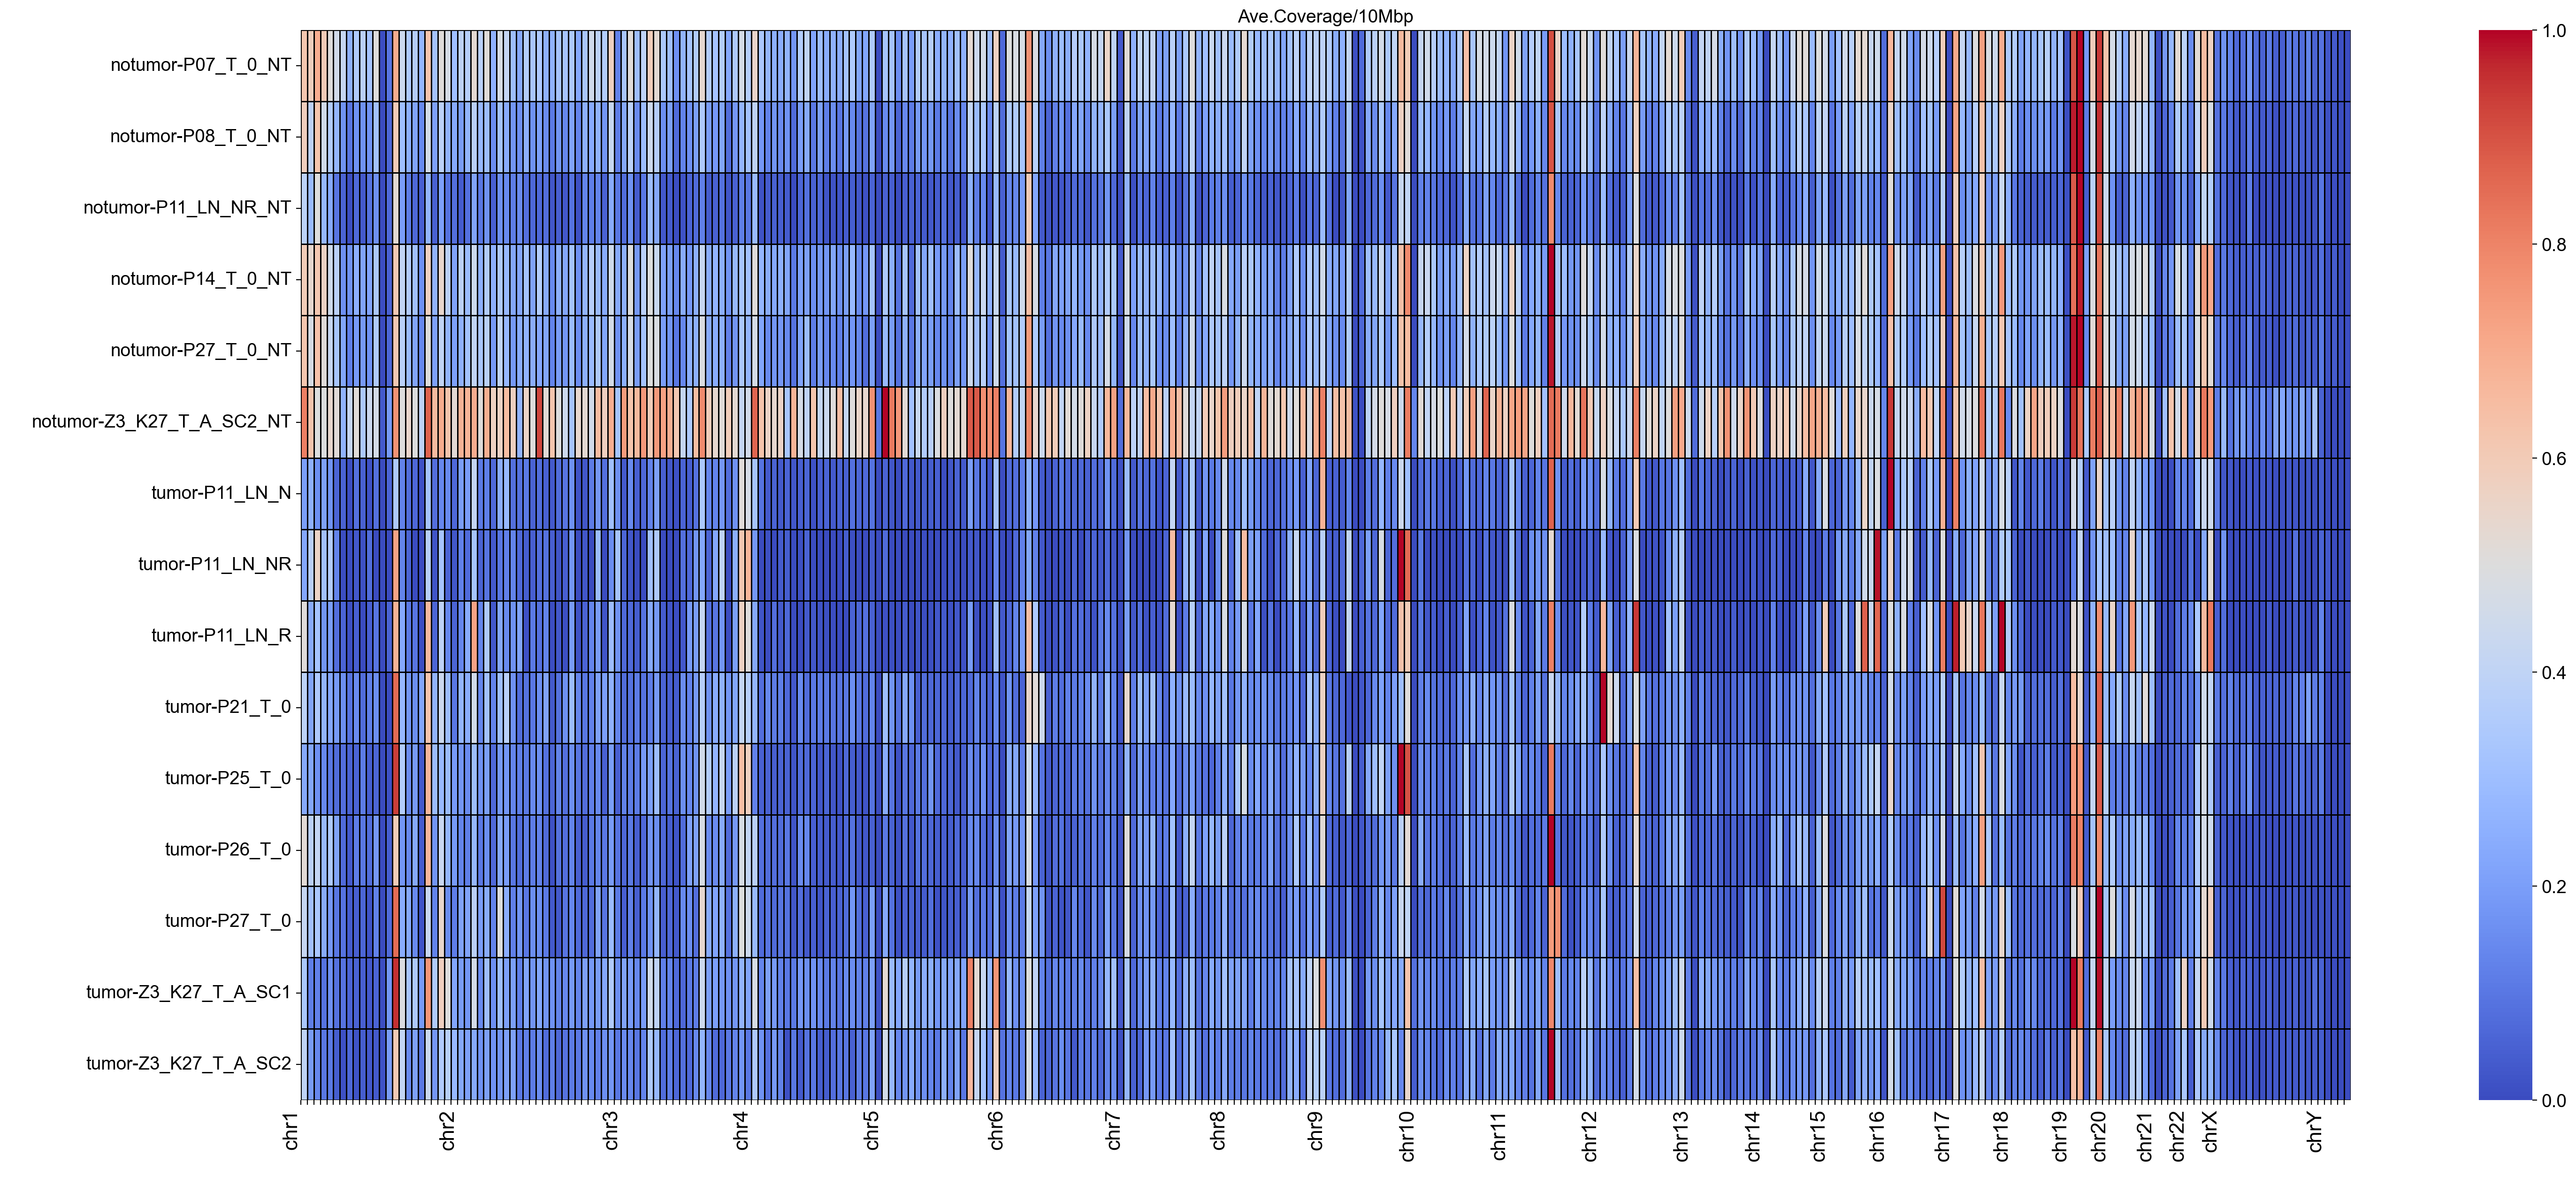

In [72]:

# 创建一个新的x轴标签列表
new_labels = []
seen_labels = set()
for label in df_normalized.columns:
    chr_name = label.split(':')[0]
    if chr_name not in seen_labels:
        new_labels.append(chr_name)
        seen_labels.add(chr_name)
    else:
        new_labels.append('')
        pass

#plt.figure(dpi=200)
plt.figure(figsize=(35,15))
#sns.heatmap(data=df_unit_sample)
# 绘制热图
font_size = 1
sns.heatmap(df_normalized, 
            #annot=False, 
            #cmap='viridis', 
            #cmap='YlGnBu',
            cmap='coolwarm',
            #square=True,
            linewidths=0.5, linecolor='black',
            #xticklabels=font_size, yticklabels=font_size,
            fmt=".3f")
plt.title('Ave.Coverage/10Mbp')
# 使用新的标签列表绘制条形图
plt.xticks(range(len(new_labels)), new_labels, fontsize=16, rotation=90, ha="right")  # 使用新的标签列表
plt.yticks(ha="right")  # 使用新的标签列表
plt.xlabel(' ')
plt.ylabel(' ') # average number of ecDNAs per cell
plt.grid(False)  # 关闭网格线
#plt.show()
#plt.savefig("D:/02.project/18.ecDNA/02.code/v0.1.1/fig/chrom_unit/f01-unit_coverage_pairs_10mbp_pancancer.pdf", bbox_inches='tight') 

In [74]:
###
import matplotlib.pyplot as plt
import anndata as ad

def sample_ecdna_sum(adata: ad.AnnData, sample: str):
    """函数文档字符串"""
    # 函数代码块
    unit = 1000000
    adata = adata.copy()

    # 使用 np.nansum()
    sum_nansum = (np.nansum(adata.X, axis=0))/(adata.shape[0])
    
    # 创建一个字典来存储每个单元的覆盖度
    coverage_counts = {}
    for ecdna, coverage in zip(adata.var.index, sum_nansum):
        chr_name, region = ecdna.split(':')
        start, end = map(int, region.split('_'))
        unit_start = start // unit * unit
        unit_end = unit_start + unit
        unit_name = f'{chr_name}:{unit_start}_{unit_end}'
        #unit_name = f'{chr_name}:{unit_start}'
        if unit_name not in coverage_counts:
            coverage_counts[unit_name] = 0
        coverage_counts[unit_name] += coverage
    
    # 创建一个列表来存储单元的名称和覆盖度
    unit_names = list(coverage_counts.keys())
    coverages = list(coverage_counts.values())
    
    # 创建一个新的列表，其中包含 (unit_name, coverage) 对
    unit_coverage_pairs = list(zip(unit_names, coverages))
    # 创建一个字典，其中包含单元名称和覆盖度
    data = {'Chromsome_Unit': [], sample: []}
    for i,j in unit_coverage_pairs:
        data['Chromsome_Unit'].append(i)
        data[sample].append(j)
        pass
    
    # 创建 Pandas DataFrame
    df = pd.DataFrame(data).T
    # 获取指定行的元素作为新的列名
    new_columns = df.loc["Chromsome_Unit",:].tolist()
    # 替换DataFrame的列名
    df.columns = new_columns
    df = df.drop(index="Chromsome_Unit")
    return df

import matplotlib.pyplot as plt
import anndata as ad

def unit_coverage_pairs(adata: ad.AnnData,unit = 10000000):
    """函数文档字符串"""
    # 函数代码块
    unit = unit
    adata = adata.copy()

    # 使用 np.nansum()
    sum_nansum = (np.nansum(adata.X, axis=0))/(adata.shape[0])  #平均覆盖度coverage
    
    # 创建一个字典来存储每个单元的覆盖度
    coverage_counts = {}
    for ecdna, coverage in zip(adata.var.index, sum_nansum):
        chr_name, region = ecdna.split(':')
        start, end = map(int, region.split('_'))
        unit_start = start // unit * unit
        unit_end = unit_start + unit
        unit_name = f'{chr_name}:{unit_start}_{unit_end}'
        #unit_name = f'{chr_name}'
        if unit_name not in coverage_counts:
            coverage_counts[unit_name] = 0
        coverage_counts[unit_name] += coverage
    
    # 创建一个列表来存储单元的名称和覆盖度
    unit_names = list(coverage_counts.keys())
    coverages = list(coverage_counts.values())
    
    ### 按照chr序号排序
    # 创建一个新的列表，其中包含 (unit_name, coverage) 对
    unit_coverage_pairs = list(zip(unit_names, coverages))
    # 对列表进行排序，排序的关键字是 unit_name
    #unit_coverage_pairs.sort(key=lambda pair: (int(pair[0].split(':')[0][3:]), int(pair[0].split(':')[1].split('_')[0])))
    unit_coverage_pairs.sort(key=lambda pair: (int(pair[0].split(':')[0][3:]) if pair[0].split(':')[0][3:].isdigit() else {'X':23,'Y':24}.get(pair[0].split(':')[0][3:]),
                                               int(pair[0].split(':')[1].split('_')[0])))
    # 从排序后的列表中获取排序后的 unit_names 和 coverages
    #sorted_unit_names, sorted_coverages = zip(*unit_coverage_pairs)
    return unit_coverage_pairs

def unit_coverage_pairs_chr(adata: ad.AnnData):
    """函数文档字符串"""
    # 函数代码块
    adata = adata.copy()
    chromosome_lengths = {
        "chr1": 248956422,"chr2": 242193529,"chr3": 198295559,"chr4": 190214555,"chr5": 181538259,"chr6": 170805979,
        "chr7": 159345973,"chr8": 145138636,"chr9": 138394717,"chr10": 133797422,"chr11": 135086622,"chr12": 133275309,
        "chr13": 114364328,"chr14": 107043718,"chr15": 101991189,"chr16": 90338345,"chr17": 83257441,"chr18": 80373285,
        "chr19": 58617616,"chr20": 64444167,"chr21": 46709983,"chr22": 50818468,"chrX": 156040895,"chrY": 57227415,
    }
    # 使用 np.nansum()
    sum_nansum = (np.nansum(adata.X, axis=0))/(adata.shape[0])  #平均覆盖度coverage
    
    # 创建一个字典来存储每个chr的覆盖度
    coverage_counts = {}
    for ecdna, coverage in zip(adata.var.index, sum_nansum):
        chr_name, region = ecdna.split(':')
        unit_name = f'{chr_name}'
        if unit_name not in coverage_counts:
            coverage_counts[unit_name] = 0
        coverage_counts[unit_name] += coverage
    
    # 创建一个列表来存储单元的名称和覆盖度
    unit_names = list(coverage_counts.keys())
    coverages = list(coverage_counts.values())
    
    ### 按照chr序号排序
    # 创建一个新的列表，其中包含 (unit_name, coverage) 对
    unit_coverage_pairs = list(zip(unit_names, coverages))
    # 对列表进行排序，排序的关键字是 unit_name
    unit_coverage_pairs.sort(key=lambda pair: (int(pair[0][3:]) if pair[0][3:].isdigit() else {'X':23,'Y':24}.get(pair[0][3:])))

    # 创建一个新的列表来存储 (unit_name, normalized_coverage) 对
    normalized_unit_coverage_pairs = []
    for unit_name, coverage in unit_coverage_pairs:
        # 获取染色体的长度
        chr_length = chromosome_lengths[unit_name]
        # 计算覆盖度的归一化值
        normalized_coverage = 1000000 * coverage / chr_length
        # 将 (unit_name, normalized_coverage) 对添加到列表中
        normalized_unit_coverage_pairs.append((unit_name, normalized_coverage))
    
    return normalized_unit_coverage_pairs
    

In [93]:
unit_temp_list = []
for adata_sample in adata_list:
    cancer = adata_sample.obs["NT"].unique()[0]
    sample = adata_sample.obs["sample"].unique()[0]
    unit_temp = unit_coverage_pairs_chr(adata_sample)
    unit_temp_list.append([cancer,sample,unit_temp])

In [104]:
df_unit_sample = pd.DataFrame()
for cancer,sample,unit_temp in unit_temp_list:
    df_temp = pd.DataFrame([dict(unit_temp)], columns=[i[0] for i in unit_temp])
    # 创建一个新的MultiIndex
    new_index = pd.MultiIndex.from_tuples([(cancer,sample)])
    # 将新的MultiIndex设置为df的索引
    df_temp.index = new_index
    #df_temp.set_index([cancer, sample], inplace=True)
    df_unit_sample = pd.concat([df_unit_sample,df_temp])

import pandas as pd
from sklearn.preprocessing import normalize,scale

# 定义排序函数
def sort_key(col_name):
    parts = col_name.split(':')
    first_part = int(parts[0][3:]) if parts[0][3:].isdigit() else {'X':23,'Y':24}.get(parts[0][3:])
    second_part = int(parts[1].split('_')[0])
    return (first_part, second_part)
# 定义排序函数
def sort_key_chr(col_name):
    parts = col_name
    first_part = parts[:3]
    second_part = int(parts[3:]) if parts[3:].isdigit() else {'X':23,'Y':24}.get(parts[3:])
    return (first_part, second_part)
# 定义放缩函数
def scale_row(row):
    return (row - row.min()) / (row.max() - row.min())

# 对列名进行排序
#sorted_columns = sorted(df_unit_sample.columns, key=sort_key) # chr:start_end
sorted_columns = sorted(df_unit_sample.columns, key=sort_key_chr) # chr 
# 重新排列 DataFrame 的列
df_unit_sample = df_unit_sample[sorted_columns].copy()
# 赋予df对象，填充缺失值
df = df_unit_sample.copy()
df = df.fillna(0)

In [107]:
df

chr1      chr2      chr3      chr4      chr5  \
notumor P07_T_0_NT         2.812855  2.529465  2.571404  2.024923  2.314746   
        P08_T_0_NT         2.349031  1.913809  1.952892  1.385301  1.628619   
tumor   P11_LN_N           0.505484  0.623943  0.663345  0.301614  0.301175   
        P11_LN_NR          0.465342  0.308159  0.535522  0.066346  0.054280   
notumor P11_LN_NR_NT       2.593368  1.707432  1.415820  0.847947  1.278621   
tumor   P11_LN_R           0.622571  0.574646  0.593332  0.151376  0.153749   
notumor P14_T_0_NT         1.477127  1.292846  1.264323  0.985862  1.170864   
tumor   P21_T_0            0.900672  0.762702  0.680826  0.430453  0.415197   
        P25_T_0            0.756721  0.553373  1.005398  0.204606  0.384348   
        P26_T_0            1.917245  1.009895  1.434099  0.687666  0.621817   
        P27_T_0            0.777062  0.682164  0.760712  0.342936  0.317320   
notumor P27_T_0_NT         2.204139  1.991135  2.005502  1.319773  1.701991   
tumor   Z3_K27_T_A_SC1     1.522657  1.301633  1.253597  1.002961  2.131565   
        Z3_K27_T_A_SC2     0.658629  0.564257  0.507066  0.402274  0.968311   
notumor Z3_K27_T_A_SC2_NT  1.451401  1.715649  1.785832  1.635673  1.857127   

                               chr6      chr7      chr8      chr9     chr10  \
notumor P07_T_0_NT         2.723140  2.414923  2.418222  2.263983  2.762678   
        P08_T_0_NT         2.159096  1.911864  1.826734  1.801144  2.083729   
tumor   P11_LN_N           0.419787  0.727043  0.801191  0.572477  0.383247   
        P11_LN_NR          0.155671  0.454529  0.651089  0.737147  0.093327   
notumor P11_LN_NR_NT       1.960219  1.645637  1.358833  1.893858  1.866763   
tumor   P11_LN_R           0.449541  0.605177  0.643356  0.599650  0.225240   
notumor P14_T_0_NT         1.287711  1.271118  1.176812  1.310592  1.569255   
tumor   P21_T_0            0.758323  0.917660  0.770556  0.517012  0.565576   
        P25_T_0            0.576193  0.578604  0.948562  1.127657  0.604858   
        P26_T_0            1.063496  1.920863  1.537484  1.078903  1.161736   
        P27_T_0            0.476742  0.602885  0.559883  0.552726  0.541445   
notumor P27_T_0_NT         2.088976  2.013875  1.963537  1.861408  2.152609   
tumor   Z3_K27_T_A_SC1     1.195263  1.202721  1.707936  1.308047  1.189843   
        Z3_K27_T_A_SC2     0.504579  0.593216  0.680640  0.579091  0.585291   
notumor Z3_K27_T_A_SC2_NT  1.577128  1.663578  1.763087  1.312427  1.718415   

                           ...     chr15     chr16     chr17     chr18  \
notumor P07_T_0_NT         ...  2.277007  2.902294  3.828710  2.086067   
        P08_T_0_NT         ...  1.873786  2.657011  3.859627  1.425541   
tumor   P11_LN_N           ...  0.983126  1.671574  1.716957  0.301037   
        P11_LN_NR          ...  0.837432  0.833640  0.778662  0.040919   
notumor P11_LN_NR_NT       ...  1.747776  3.546050  5.613033  0.902365   
tumor   P11_LN_R           ...  1.157032  1.278596  2.336671  0.140529   
notumor P14_T_0_NT         ...  1.191966  1.745637  2.197979  1.109727   
tumor   P21_T_0            ...  0.512898  0.847619  0.819519  0.386454   
        P25_T_0            ...  0.723918  0.918960  1.333970  0.303284   
        P26_T_0            ...  1.079416  1.878890  2.372995  0.911240   
        P27_T_0            ...  0.497601  1.252290  1.313863  0.333952   
notumor P27_T_0_NT         ...  1.840355  2.603676  3.494809  1.640005   
tumor   Z3_K27_T_A_SC1     ...  1.272317  1.214519  2.291251  0.635064   
        Z3_K27_T_A_SC2     ...  0.464486  0.563525  1.006581  0.343423   
notumor Z3_K27_T_A_SC2_NT  ...  1.092680  1.616084  1.623561  1.587505   

                               chr19     chr20     chr21     chr22      chrX  \
notumor P07_T_0_NT          5.007017  3.144000  2.052178  2.718279  0.680055   
        P08_T_0_NT          5.744500  2.777818  1.447460  2.781847  0.444755   
tumor   P11_LN_N            1.496702  1.214128  0.267262  1.214682  0.091199

In [110]:
#df_normalized = df.copy()
# 对 df 的每一行进行归一化处理
df_normalized = df.apply(lambda x: pd.Series(normalize(x.values.reshape(1, -1), axis=1)[0]), axis=1)
#df_normalized = df.apply(lambda x: pd.Series(scale(x.values.reshape(1, -1), axis=1)[0]), axis=1)
df_normalized.index = df.index.copy()
#df = df_normalized.copy()
# 对 df 的每一行进行放缩处理
#df_normalized = df.apply(scale_row, axis=1)

sorted_df_normalized = df_normalized.sort_index(level=0)
df_normalized = sorted_df_normalized.copy()

In [ ]:
# 创建一个新的x轴标签列表
new_labels_x = []
seen_labels_x = set()
for label in df_normalized.columns:
    #chr_name = label.split(':')[0]
    chr_name = label
    if chr_name not in seen_labels_x:
        new_labels_x.append(chr_name)
        seen_labels_x.add(chr_name)
    else:
        new_labels_x.append('')
        pass
# 创建一个新的y轴标签列表
new_labels_y = []
seen_labels_y = set()
for cancer,sample in df_normalized.index:
    if cancer not in seen_labels_y:
        new_labels_y.append(cancer)
        seen_labels_y.add(cancer)
    else:
        new_labels_y.append('')
        pass
        
#plt.figure(dpi=200)
plt.figure(figsize=(6,6))
#sns.heatmap(data=df_unit_sample)
# 绘制热图
font_size = 1
sns.heatmap(df_normalized.T, 
            #annot=False, 
            #cmap='viridis', 
            #cmap='YlGnBu',
            cmap='coolwarm',
            square=True,
            linewidths=0.1, linecolor='black',
            #xticklabels=font_size, yticklabels=font_size,
            fmt=".3f")
plt.title('Ave.Coverage/Chromosome')
#plt.title('Ave.#.ecDNA/10Mbp')
# 使用新的标签列表绘制条形图
#plt.yticks(range(len(new_labels_x)), new_labels_x, fontsize=16, rotation=0, ha="right")  # 使用新的标签列表
plt.yticks(fontsize=10, rotation=0, ha="right")
plt.xticks(range(len(new_labels_y)), new_labels_y, fontsize=12, rotation=90, ha="right")  # 使用新的标签列表
plt.xlabel(' ')
plt.ylabel(' ') # average number of ecDNAs per cell
plt.legend(title='Z score', bbox_to_anchor=(1.01, 1), loc=2, borderaxespad=0.)
plt.grid(False)  # 关闭网格线
#plt.show()
#plt.savefig("./f08-upsetplot_pan-cancer_high-10_chromunit-10M_1.pdf", bbox_inches='tight') 
#plt.savefig(f"D:/02.project/18.ecDNA/02.code/v0.1.1/fig/chrom_unit/f02-unit_coverage_pairs_chr_pancancer.pdf", bbox_inches='tight') 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


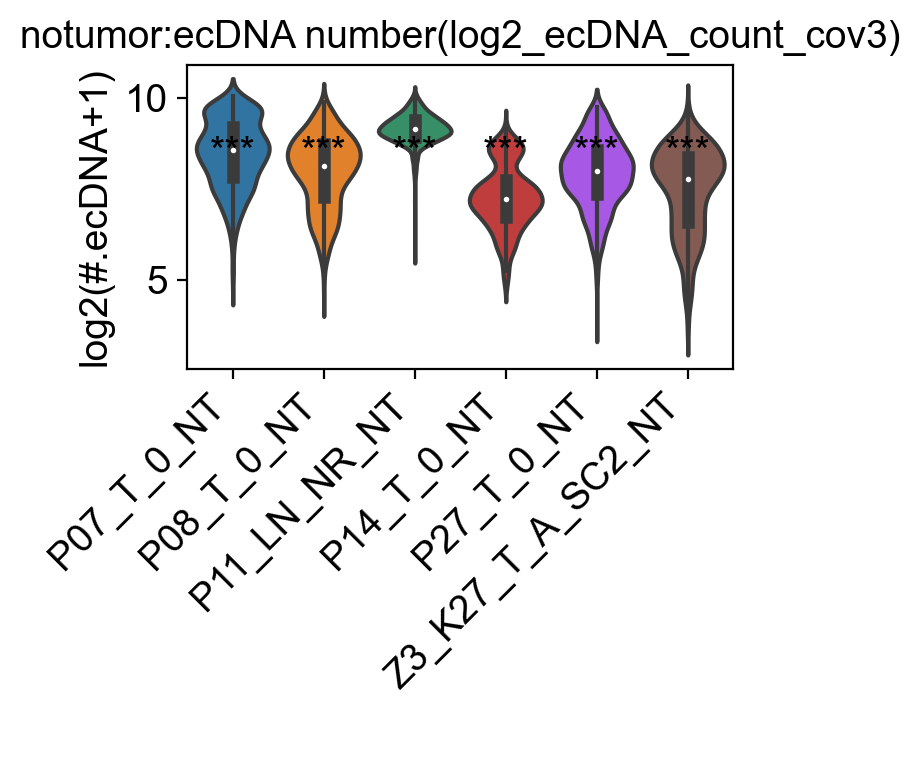

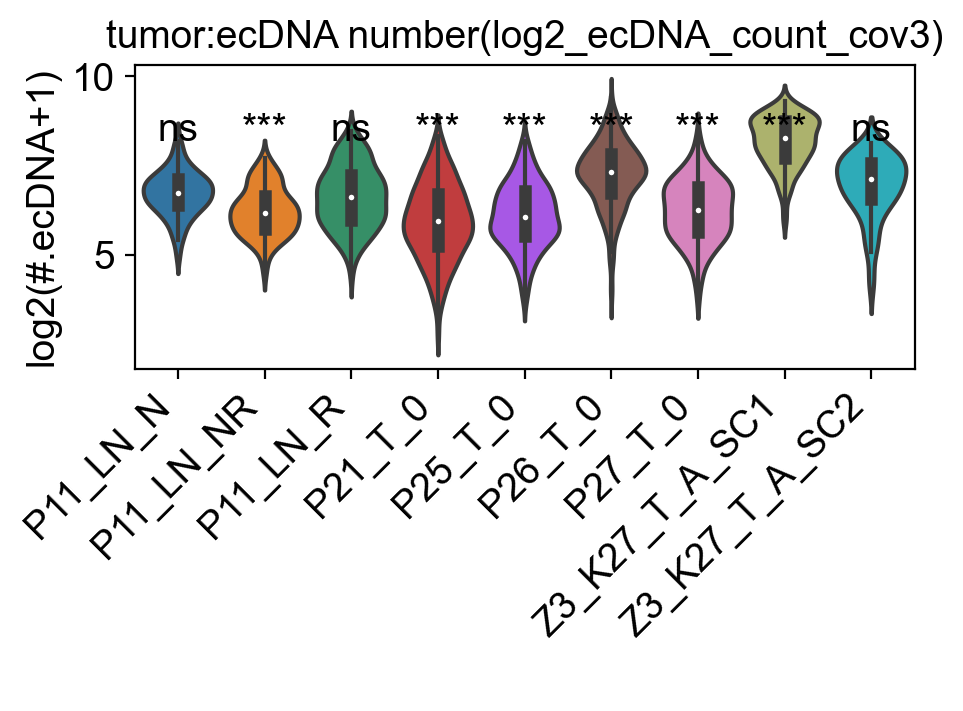

In [21]:
for cancer in list(set(df_cancer_sample_cell["cancer"].to_list())):
    df = df_cancer_sample_cell[df_cancer_sample_cell["cancer"] == cancer].copy()
    df['ecDNA_count_cov3'] = pd.to_numeric(df['ecDNA_count_cov3'], errors='coerce')
    df = df[df["ecDNA_count_cov3"]>0]
    df['log2_ecDNA_count_cov3'] = np.log2(df['ecDNA_count_cov3']+1)
    
    # 获取所有的Sample_types
    Sample_types = df['sample'].unique()
    # 对每一对Sample_types类型进行差异检验，并保存 统计量和 p 值
    stats = []
    p_values = {}
    for i in range(len(Sample_types)):
        type1 = Sample_types[i]
        data1 = df[df['sample'] == type1]['log2_ecDNA_count_cov3']
        data2 = df[df['sample'] != type1]['log2_ecDNA_count_cov3']
        t_stat, t_stat_p_val = ttest_ind(data1, data2) # t检验
        u_stat, u_stat_p_val = mannwhitneyu(data1, data2) # 秩和检验
        ks_stat, ks_stat_p_val = ks_2samp(data1, data2) # Kolmogorov-Smirnov 检验
        p_values[type1] = t_stat_p_val
        stats.append((type1, t_stat, t_stat_p_val, u_stat, u_stat_p_val, ks_stat, ks_stat_p_val))
    
    # 将结果整理为数据框
    df_stats = pd.DataFrame(stats, columns=['sample', 't_stat', 't_stat_p_val', 'u_stat', 'u_stat_p_val', 'ks_stat', 'ks_stat_p_val'])
    #df_stats.to_csv(f"./fig_100k_merge_3/stat_cov3/f02-violin/f02-df_cancer_sample_cell-{cancer}-ecDNA_count_cov0-log2_p_values.tsv", sep='\t', index=False)
    
    # 创建图形
    # 根据样本数量确定图形宽度
    width = max(2, (len(df['sample'].unique())+1) * 0.5)
    # 绘制小提琴图
    plt.figure(figsize=(width, 2))  # 调整图形的大小
    sns.violinplot(x='sample', y='log2_ecDNA_count_cov3', data=df, scale="width")
    #sns.boxplot(x='Sample', y='log2_ecdna_count',data=df, width=0.2, showfliers=False)
    #sns.stripplot(x='Sample', y='log2_ecdna_count', data=df, color="0.05",size=4)
    
    # 添加 p 值注释
    for i, type1 in enumerate(Sample_types):
        p_val = p_values[type1]
        if p_val < 0.001:
            p_text = '***'
        elif p_val < 0.01:
            p_text = '**'
        elif p_val < 0.05:
            p_text = '*'
        else:
            p_text = 'ns'
        plt.text(i, 8.2, p_text, ha='center')
    
    #plt.ylim(0,9.5)
    #plt.yticks(np.arange(0, 10, 2))  # 设置 y 轴的刻度标签
    plt.xlabel(' ')
    plt.ylabel('log2(#.ecDNA+1)')
    #plt.ylabel('#.ecDNA')
    plt.title(f'{cancer}:ecDNA number(log2_ecDNA_count_cov3)')
    plt.xticks(rotation=45,ha="right") # 将x轴的标签更改为倾斜字体
    plt.grid(False)  # 关闭网格线
    #plt.show()
    #plt.savefig(f"./fig_100k_merge_3/stat_cov3/f02-violin/f02-df_cancer_sample_cell-{cancer}-ecDNA_count_cov0-log2_violinplot.pdf", bbox_inches='tight')


In [53]:
# 统计coverage>=6的ecDNA数量
df_cell_log = df_cancer_sample_cell.copy()
df_cell_log['ecDNA_count_cov3'] = pd.to_numeric(df_cell_log['ecDNA_count_cov3'], errors='coerce')
df_cell_log = df_cell_log[df_cell_log["ecDNA_count_cov3"]>0]
df_cell_log['log2_ecDNA_count_cov3'] = np.log2(df_cell_log['ecDNA_count_cov3']+1)
#df_cell_log.to_csv(f"./fig_100k_merge_3/stat_cov3/f02-df_cancer_sample_cell_log2.tsv", sep='\t', index=False)

# 根据样本数量确定图形宽度
width = max(len(df_cell_log['sample'].unique())*0.25,5)
# 绘制小提琴图
plt.figure(figsize=(10, 5))  # 调整图形的大小
sns.boxplot(x='sample', y='log2_ecDNA_count_cov3', hue='cancer', 
            data=df_cell_log, width=1, showfliers=True)
plt.xlabel('sample')
plt.ylabel('log2(#.ecDNA+1)')
plt.title('ecDNA number (Coverage>3)')
plt.xticks(rotation=45,ha="right") # 将x轴的标签更改为倾斜字体
#plt.legend(title='Cancer Type')  # 添加图例标题
plt.legend(bbox_to_anchor=(1.01, 1), loc=2, borderaxespad=0.)
#plt.show()
# 保存图形为PDF文件
#plt.savefig(f"./fig_100k_merge_3/stat_cov3/f02-df_cancer_sample_cell_log2_boxplot.pdf", bbox_inches='tight')


ValueError: Invalid RGBA argument: 'cancer'

<Figure size 1000x500 with 0 Axes>

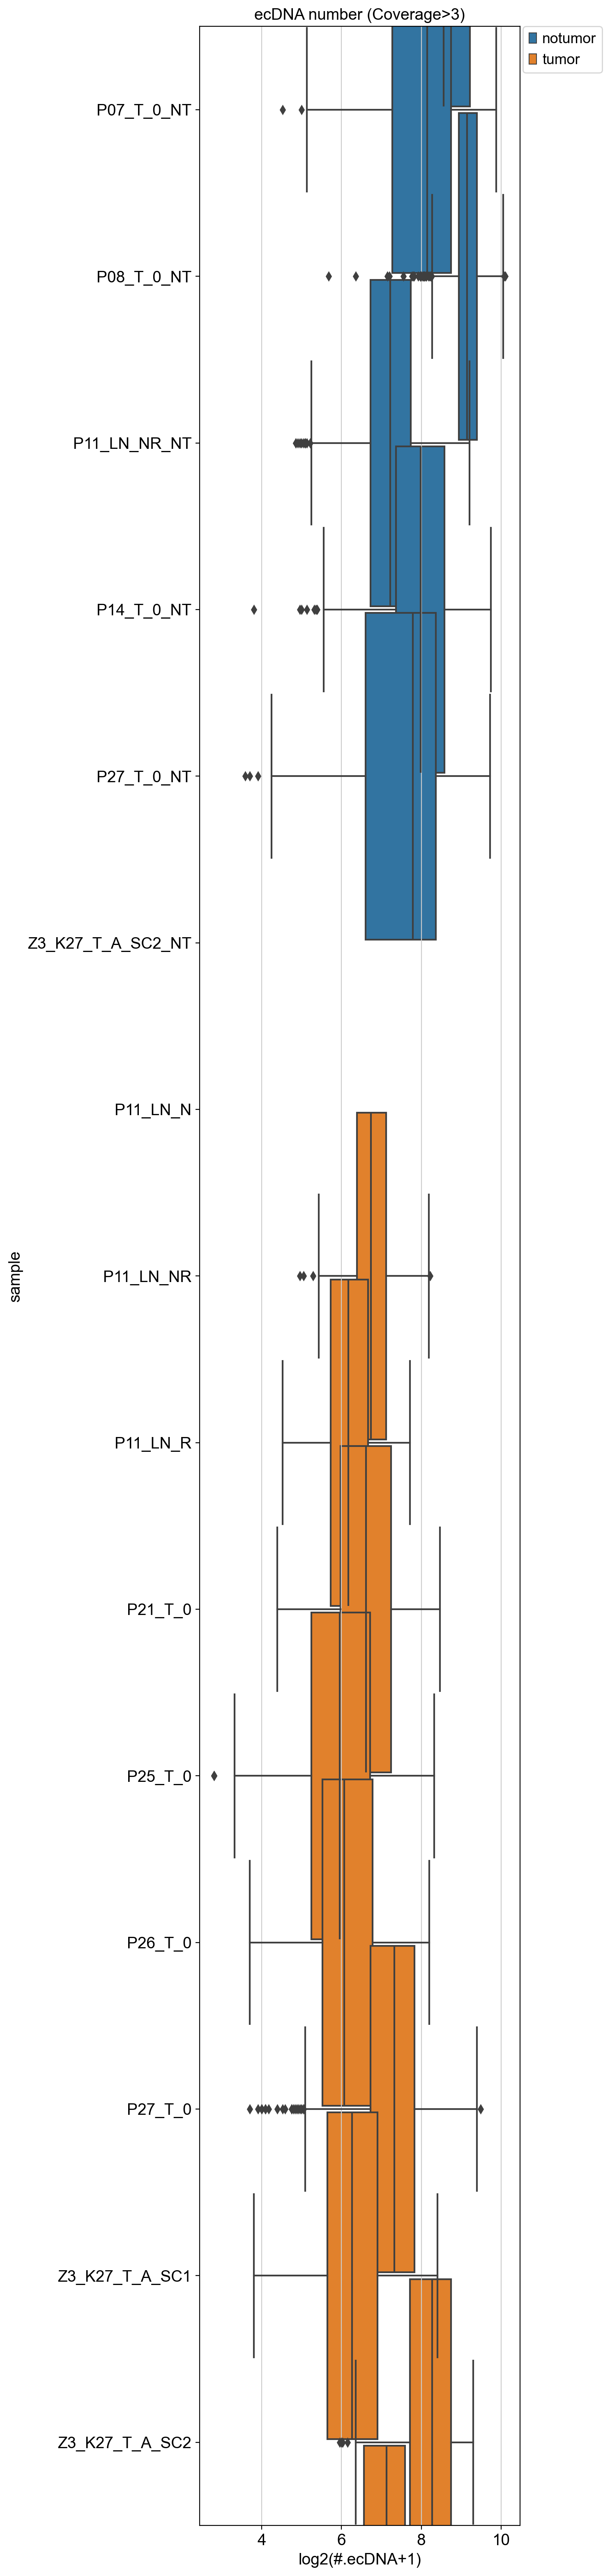

In [27]:
# 根据样本数量确定图形宽度
width = max(len(df_cell_log['sample'].unique())*0.25,5)
# 绘制小提琴图
plt.figure(figsize=(5, 40))  # 调整图形的大小
sns.boxplot(y='sample', x='log2_ecDNA_count_cov3', hue='cancer', data=df_cell_log, width=4, showfliers=True)
plt.ylabel('sample')
plt.xlabel('log2(#.ecDNA+1)')
plt.title('ecDNA number (Coverage>3)')
plt.yticks(rotation=0,ha="right") # 将x轴的标签更改为倾斜字体
#plt.legend(title='Cancer Type')  # 添加图例标题
plt.legend(bbox_to_anchor=(1.01, 1), loc=2, borderaxespad=0.)
#plt.show()
# 保存图形为PDF文件
#plt.savefig(f"./fig_100k_merge_3/stat_cov3/f02-df_cancer_sample_cell_log2_boxplot_2.pdf", bbox_inches='tight')
